<a href="https://colab.research.google.com/github/tnwlvos/Purdue-AI-education-Muchine-Learning-/blob/main/FSSW_Audio_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FSSW 5-stage Audio Classification

연속 음향에서 다음 다섯 공정 단계를 분류하고 stage 전환 경계를 검출한다.

- OFF
- Approach
- Plunge
- Dwell
- Retract

모델 개발에는 development_A와 development_B만 사용한다. 실험 19~27의 test_holdout은 모델 구조와 학습 조건을 결정한 뒤 최종 평가에 한 번만 사용한다.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 라이브러리 불러오기

음원 처리, Mel-spectrogram 생성, 데이터 관리 및 시각화에 필요한 라이브러리를 불러온다.

In [2]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

## 프로젝트 경로와 stage 정보 설정

Google Drive 프로젝트 폴더, metadata, 연속 5-stage 음원과 앞으로 생성할 Log-Mel cache의 위치를 설정한다.

In [4]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "Friction Stir Spot Welding (FSSW)"
)

METADATA_DIR = (
    PROJECT_DIR / "[3] metadata"
)

SEQUENCE_DIR = (
    PROJECT_DIR
    / "[2] processed sound data"
    / "[6] continuous stage sequence"
)

FIVE_STAGE_MEL_DIR = (
    PROJECT_DIR
    / "[7] 5-stage mel spectrogram"
)

TIMELINE_MANIFEST_PATH = (
    METADATA_DIR
    / "timeline_manifest.csv"
)

STAGE_TO_ID = {
    "off": 0,
    "approach": 1,
    "plunge": 2,
    "dwell": 3,
    "retract": 4,
}

ID_TO_STAGE = {
    stage_id: stage_name
    for stage_name, stage_id
    in STAGE_TO_ID.items()
}

print(
    "프로젝트 폴더 존재:",
    PROJECT_DIR.exists(),
)

print(
    "연속 음원 폴더 존재:",
    SEQUENCE_DIR.exists(),
)

print(
    "타임라인 manifest 존재:",
    TIMELINE_MANIFEST_PATH.exists(),
)

프로젝트 폴더 존재: True
연속 음원 폴더 존재: True
타임라인 manifest 존재: True


## 5-stage 타임라인 manifest 불러오기

1초 window, 0.25초 hop으로 생성한 최종 타임라인 정보를 불러온다.

각 행에는 중심 시각의 stage, stage별 포함 비율, 경계 포함 여부와 경계 위치가 저장되어 있다.

In [5]:
timeline_manifest = pd.read_csv(
    TIMELINE_MANIFEST_PATH
)

print(
    "전체 윈도우 수:",
    len(timeline_manifest),
)

print(
    "전체 컬럼 수:",
    len(timeline_manifest.columns),
)

display(timeline_manifest.head())

전체 윈도우 수: 5260
전체 컬럼 수: 21


,timeline_window_id,experiment_id,dataset_role,relative_path,window_index,window_start_sec,window_end_sec,window_center_sec,center_stage,center_stage_id,...,target_approach,target_plunge,target_dwell,target_retract,boundary_present,boundary_index,from_stage,to_stage,boundary_sec,boundary_offset_sec
0,timeline_000001,1,development_A,[2] processed sound data/[6] continuous stage ...,0,0.00,1.00,0.50,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
1,timeline_000002,1,development_A,[2] processed sound data/[6] continuous stage ...,1,0.25,1.25,0.75,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
2,timeline_000003,1,development_A,[2] processed sound data/[6] continuous stage ...,2,0.50,1.50,1.00,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
3,timeline_000004,1,development_A,[2] processed sound data/[6] continuous stage ...,3,0.75,1.75,1.25,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
4,timeline_000005,1,development_A,[2] processed sound data/[6] continuous stage ...,4,1.00,2.00,1.50,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN


## 타임라인 데이터 검증

필수 컬럼, WAV 경로, 윈도우 길이, 중복 데이터와 분할별 stage 구성을 검사한다.

In [6]:
required_columns = [
    "timeline_window_id",
    "experiment_id",
    "dataset_role",
    "relative_path",
    "window_start_sec",
    "window_end_sec",
    "window_center_sec",
    "center_stage",
    "center_stage_id",
    "target_off",
    "target_approach",
    "target_plunge",
    "target_dwell",
    "target_retract",
    "boundary_present",
    "boundary_index",
    "from_stage",
    "to_stage",
    "boundary_sec",
    "boundary_offset_sec",
]

missing_columns = [
    column
    for column in required_columns
    if column not in timeline_manifest.columns
]

missing_path_count = sum(
    not (
        PROJECT_DIR / relative_path
    ).exists()
    for relative_path
    in timeline_manifest[
        "relative_path"
    ].unique()
)

window_duration = (
    timeline_manifest["window_end_sec"]
    - timeline_manifest[
        "window_start_sec"
    ]
)

duplicate_count = (
    timeline_manifest[
        [
            "experiment_id",
            "window_start_sec",
            "window_end_sec",
        ]
    ]
    .duplicated()
    .sum()
)

stage_id_mismatch_count = (
    timeline_manifest.apply(
        lambda row: (
            STAGE_TO_ID[row["center_stage"]]
            != row["center_stage_id"]
        ),
        axis=1,
    )
    .sum()
)

print(
    "누락된 필수 컬럼:",
    missing_columns,
)

print(
    "존재하지 않는 WAV 경로:",
    missing_path_count,
)

print(
    "윈도우 최소 길이:",
    window_duration.min(),
)

print(
    "윈도우 최대 길이:",
    window_duration.max(),
)

print(
    "중복 윈도우:",
    duplicate_count,
)

print(
    "Stage ID 불일치:",
    stage_id_mismatch_count,
)

print(
    "경계 포함 윈도우:",
    timeline_manifest[
        "boundary_present"
    ].sum(),
)

print("\n분할 및 stage별 윈도우 수:")

display(
    pd.crosstab(
        timeline_manifest[
            "dataset_role"
        ],
        timeline_manifest[
            "center_stage"
        ],
        margins=True,
    )
)

누락된 필수 컬럼: []
존재하지 않는 WAV 경로: 0
윈도우 최소 길이: 1.0
윈도우 최대 길이: 1.0
중복 윈도우: 0
Stage ID 불일치: 0
경계 포함 윈도우: 513

분할 및 stage별 윈도우 수:


center_stage,approach,dwell,off,plunge,retract,All
dataset_role,,,,,,
development_A,459,252,108,243,690,1752
development_B,459,252,108,243,692,1754
test_holdout,459,252,108,243,692,1754
All,1377,756,324,729,2074,5260


## Log-Mel spectrogram 설정

각 1초 오디오 윈도우에 STFT를 적용하고, Power spectrogram을 64개의 Mel 주파수 대역으로 변환한 뒤 고정 기준의 dB 스케일로 변환한다.

각 spectrogram의 최댓값으로 개별 정규화하지 않아 stage 사이의 실제 음향 에너지 차이를 유지한다.

In [7]:
SAMPLE_RATE = 48000
AUDIO_WINDOW_SEC = 1.0
AUDIO_WINDOW_FRAMES = int(
    SAMPLE_RATE * AUDIO_WINDOW_SEC
)

N_FFT = 2048
STFT_HOP_LENGTH = 512
N_MELS = 64
FMIN = 50
FMAX = 12000
TOP_DB = 80


def read_audio_window(
    relative_path,
    start_sec,
):
    audio_path = (
        PROJECT_DIR / relative_path
    )

    with sf.SoundFile(
        str(audio_path),
        "r",
    ) as audio_file:
        if (
            audio_file.samplerate
            != SAMPLE_RATE
        ):
            raise ValueError(
                f"샘플링레이트 오류: "
                f"{audio_path.name}"
            )

        start_frame = int(
            round(
                float(start_sec)
                * SAMPLE_RATE
            )
        )

        audio_file.seek(start_frame)

        audio = audio_file.read(
            AUDIO_WINDOW_FRAMES,
            dtype="float32",
            always_2d=False,
        )

    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    if len(audio) != AUDIO_WINDOW_FRAMES:
        raise ValueError(
            f"1초 길이가 아닌 윈도우: "
            f"{audio_path.name}, "
            f"{start_sec}초"
        )

    return audio


def make_log_mel(audio):
    mel_power = (
        librosa.feature.melspectrogram(
            y=audio,
            sr=SAMPLE_RATE,
            n_fft=N_FFT,
            hop_length=STFT_HOP_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
            power=2.0,
            center=False,
        )
    )

    log_mel = librosa.power_to_db(
        mel_power,
        ref=1.0,
        top_db=TOP_DB,
    )

    return log_mel.astype(
        np.float32
    )


example_mel = make_log_mel(
    np.zeros(
        AUDIO_WINDOW_FRAMES,
        dtype=np.float32,
    )
)

print(
    "Log-Mel shape:",
    example_mel.shape,
)

Log-Mel shape: (64, 90)


## 다섯 stage의 순수 Log-Mel 비교

development_A에서 하나의 stage만 100% 포함된 윈도우를 stage별로 한 개씩 선택한다.

동일한 색상 범위를 사용해 음량과 주파수 분포를 직접 비교한다. test_holdout은 시각화에 사용하지 않는다.

off | experiment: 4 | start: 0.75 | shape: (64, 90)
approach | experiment: 4 | start: 3.0 | shape: (64, 90)
plunge | experiment: 8 | start: 15.5 | shape: (64, 90)
dwell | experiment: 9 | start: 27.5 | shape: (64, 90)
retract | experiment: 5 | start: 39.75 | shape: (64, 90)


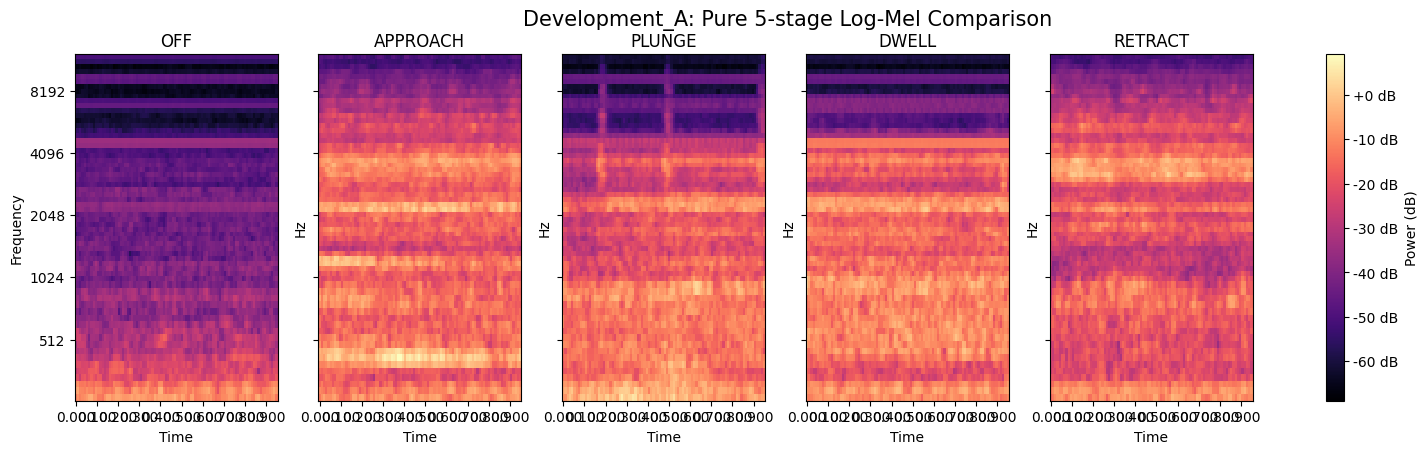

In [8]:
stage_order = [
    "off",
    "approach",
    "plunge",
    "dwell",
    "retract",
]

pure_stage_examples = []
pure_stage_mels = []

for stage_name in stage_order:
    target_column = (
        f"target_{stage_name}"
    )

    candidates = timeline_manifest[
        (
            timeline_manifest[
                "dataset_role"
            ] == "development_A"
        )
        & (
            timeline_manifest[
                target_column
            ] >= 1.0 - 1e-9
        )
    ]

    selected_row = candidates.sample(
        n=1,
        random_state=42,
    ).iloc[0]

    audio = read_audio_window(
        selected_row["relative_path"],
        selected_row[
            "window_start_sec"
        ],
    )

    log_mel = make_log_mel(audio)

    pure_stage_examples.append(
        selected_row
    )
    pure_stage_mels.append(
        log_mel
    )

    print(
        stage_name,
        "| experiment:",
        int(
            selected_row[
                "experiment_id"
            ]
        ),
        "| start:",
        selected_row[
            "window_start_sec"
        ],
        "| shape:",
        log_mel.shape,
    )

shared_vmin = min(
    mel.min()
    for mel in pure_stage_mels
)

shared_vmax = max(
    mel.max()
    for mel in pure_stage_mels
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(19, 4.5),
    sharex=True,
    sharey=True,
)

last_image = None

for axis, stage_name, log_mel in zip(
    axes,
    stage_order,
    pure_stage_mels,
):
    last_image = librosa.display.specshow(
        log_mel,
        sr=SAMPLE_RATE,
        hop_length=STFT_HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
        vmin=shared_vmin,
        vmax=shared_vmax,
        cmap="magma",
        ax=axis,
    )

    axis.set_title(
        stage_name.upper()
    )

    axis.set_xlabel("Time")

axes[0].set_ylabel("Frequency")

fig.colorbar(
    last_image,
    ax=axes,
    format="%+2.0f dB",
    label="Power (dB)",
)

fig.suptitle(
    "Development_A: Pure 5-stage Log-Mel Comparison",
    fontsize=15,
)

plt.show()

## 다섯 종류 경계의 혼합 Log-Mel 비교

development_A에서 경계가 윈도우 중심에 가장 가까운 사례를 경계 종류별로 선택한다.

빨간 점선은 실제 stage 경계 위치를 나타낸다. 경계 전후로 음향 패턴이 어떻게 변화하는지 확인한다.

In [14]:
boundary_transitions = [
    ("off", "approach"),
    ("approach", "plunge"),
    ("plunge", "dwell"),
    ("dwell", "retract"),
    ("retract", "off"),
]

boundary_example_rows = []
boundary_example_mels = []

for from_stage, to_stage in (
    boundary_transitions
):
    candidates = timeline_manifest[
        (
            timeline_manifest[
                "dataset_role"
            ] == "development_A"
        )
        & (
            timeline_manifest[
                "boundary_present"
            ]
        )
        & (
            timeline_manifest[
                "from_stage"
            ] == from_stage
        )
        & (
            timeline_manifest[
                "to_stage"
            ] == to_stage
        )
    ].copy()

    candidates[
        "center_distance"
    ] = (
        candidates[
            "boundary_offset_sec"
        ]
        - 0.5
    ).abs()

    selected_row = (
        candidates
        .sort_values(
            [
                "center_distance",
                "experiment_id",
            ]
        )
        .iloc[0]
    )

    audio = read_audio_window(
        selected_row["relative_path"],
        selected_row[
            "window_start_sec"
        ],
    )

    log_mel = make_log_mel(audio)

    boundary_example_rows.append(
        selected_row
    )
    boundary_example_mels.append(
        log_mel
    )

    print(
        f"{from_stage} → {to_stage}",
        "| experiment:",
        int(
            selected_row[
                "experiment_id"
            ]
        ),
        "| boundary offset:",
        selected_row[
            "boundary_offset_sec"
        ],
        "| from fraction:",
        selected_row[
            f"target_{from_stage}"
        ],
        "| to fraction:",
        selected_row[
            f"target_{to_stage}"
        ],
    )



off → approach | experiment: 1 | boundary offset: 0.5 | from fraction: 0.5 | to fraction: 0.5
approach → plunge | experiment: 1 | boundary offset: 0.5099999999999998 | from fraction: 0.5099999999999998 | to fraction: 0.4900000000000002
plunge → dwell | experiment: 1 | boundary offset: 0.5100000000000016 | from fraction: 0.5100000000000016 | to fraction: 0.4899999999999984
dwell → retract | experiment: 1 | boundary offset: 0.5100000000000016 | from fraction: 0.5100000000000016 | to fraction: 0.4899999999999984
retract → off | experiment: 5 | boundary offset: 0.4969999999999999 | from fraction: 0.4969999999999999 | to fraction: 0.5030000000000001


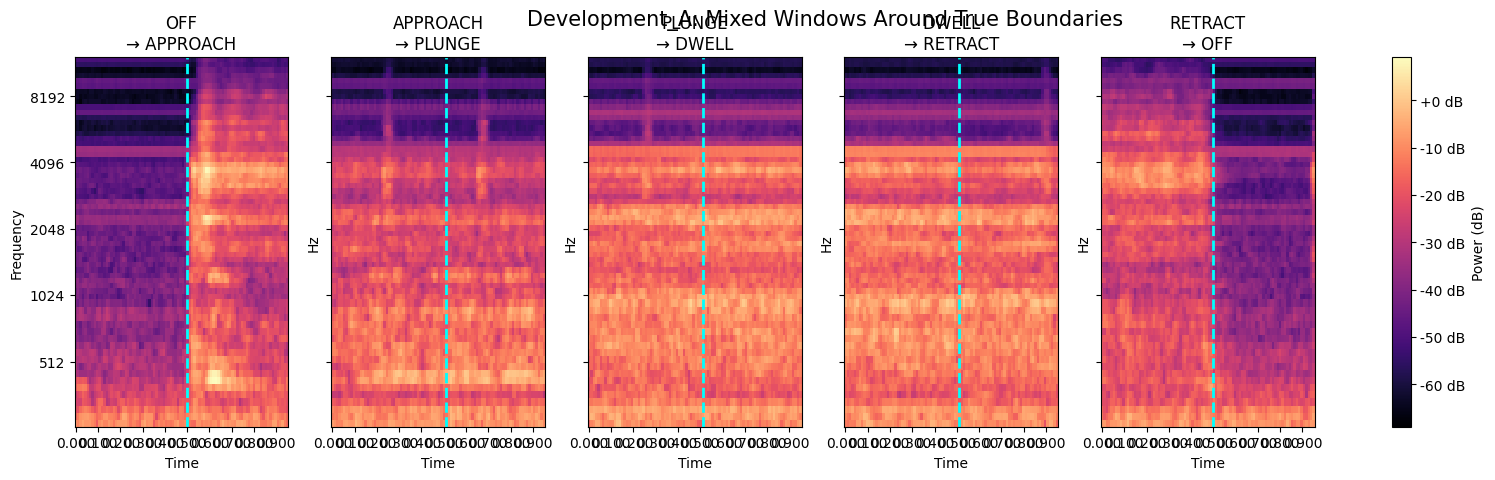

In [15]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4.8),
    sharex=True,
    sharey=True,
)

last_image = None

for (
    axis,
    transition,
    selected_row,
    log_mel,
) in zip(
    axes,
    boundary_transitions,
    boundary_example_rows,
    boundary_example_mels,
):
    from_stage, to_stage = transition

    last_image = librosa.display.specshow(
        log_mel,
        sr=SAMPLE_RATE,
        hop_length=STFT_HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
        vmin=shared_vmin,
        vmax=shared_vmax,
        cmap="magma",
        ax=axis,
    )

    axis.axvline(
        selected_row[
            "boundary_offset_sec"
        ],
        color="cyan",
        linestyle="--",
        linewidth=2,
        label="True boundary",
    )

    axis.set_title(
        f"{from_stage.upper()}\n→ "
        f"{to_stage.upper()}"
    )

    axis.set_xlabel("Time")

axes[0].set_ylabel("Frequency")

fig.colorbar(
    last_image,
    ax=axes,
    format="%+2.0f dB",
    label="Power (dB)",
)

fig.suptitle(
    "Development_A: Mixed Windows Around True Boundaries",
    fontsize=15,
)

plt.show()

## 개발 데이터의 경계 전후 음향 특징 계산

development_A/B의 실제 경계를 기준으로 -1.5초부터 +1.5초까지 0.25초 간격으로 1초 윈도우를 생성한다.

각 윈도우에서 RMS, 평균 Log-Mel 에너지, spectral centroid와 이전 윈도우 대비 Mel 변화량을 계산한다. test_holdout은 사용하지 않는다.

In [17]:
development_boundaries = (
    timeline_manifest[
        (
            timeline_manifest[
                "dataset_role"
            ].isin(
                [
                    "development_A",
                    "development_B",
                ]
            )
        )
        & (
            timeline_manifest[
                "boundary_present"
            ]
        )
    ][
        [
            "experiment_id",
            "dataset_role",
            "relative_path",
            "boundary_index",
            "from_stage",
            "to_stage",
            "boundary_sec",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "experiment_id",
            "boundary_index",
        ]
    )
    .reset_index(drop=True)
)

relative_center_times = np.arange(
    -1.5,
    1.5 + 1e-9,
    0.25,
)

boundary_feature_records = []

print(
    "개발 경계 수:",
    len(development_boundaries),
)

for experiment_id, experiment_boundaries in (
    development_boundaries.groupby(
        "experiment_id"
    )
):
    relative_path = (
        experiment_boundaries[
            "relative_path"
        ].iloc[0]
    )

    sequence_path = (
        PROJECT_DIR / relative_path
    )

    sequence_audio, sequence_sr = sf.read(
        str(sequence_path),
        dtype="float32",
        always_2d=False,
    )

    if sequence_audio.ndim == 2:
        sequence_audio = (
            sequence_audio.mean(axis=1)
        )

    if sequence_sr != SAMPLE_RATE:
        raise ValueError(
            f"{experiment_id}번 "
            "샘플링레이트 오류"
        )

    for boundary in (
        experiment_boundaries.itertuples()
    ):
        boundary_profiles = []

        for relative_center_sec in (
            relative_center_times
        ):
            window_center_sec = (
                boundary.boundary_sec
                + relative_center_sec
            )

            window_start_sec = (
                window_center_sec
                - AUDIO_WINDOW_SEC / 2
            )

            start_frame = int(
                round(
                    window_start_sec
                    * SAMPLE_RATE
                )
            )

            end_frame = (
                start_frame
                + AUDIO_WINDOW_FRAMES
            )

            audio_window = sequence_audio[
                start_frame:end_frame
            ]

            if (
                len(audio_window)
                != AUDIO_WINDOW_FRAMES
            ):
                raise ValueError(
                    f"{experiment_id}번 "
                    f"{boundary.from_stage}→"
                    f"{boundary.to_stage} "
                    "윈도우 길이 오류"
                )

            log_mel = make_log_mel(
                audio_window
            )

            mel_profile = log_mel.mean(
                axis=1
            )

            rms = np.sqrt(
                np.mean(
                    audio_window.astype(
                        np.float64
                    ) ** 2
                )
            )

            rms_db = (
                20.0
                * np.log10(
                    rms + 1e-12
                )
            )

            spectral_centroid = (
                librosa.feature
                .spectral_centroid(
                    y=audio_window,
                    sr=SAMPLE_RATE,
                    n_fft=N_FFT,
                    hop_length=(
                        STFT_HOP_LENGTH
                    ),
                    center=False,
                )
                .mean()
            )

            boundary_profiles.append({
                "experiment_id": int(
                    experiment_id
                ),
                "dataset_role": (
                    boundary.dataset_role
                ),
                "boundary_index": int(
                    boundary.boundary_index
                ),
                "from_stage": (
                    boundary.from_stage
                ),
                "to_stage": (
                    boundary.to_stage
                ),
                "relative_center_sec": float(
                    relative_center_sec
                ),
                "rms_db": float(
                    rms_db
                ),
                "mean_log_mel_db": float(
                    log_mel.mean()
                ),
                "spectral_centroid_hz": (
                    float(
                        spectral_centroid
                    )
                ),
                "mel_profile": (
                    mel_profile
                ),
            })

        previous_mel_profile = None

        for profile in boundary_profiles:
            current_mel_profile = profile[
                "mel_profile"
            ]

            if previous_mel_profile is None:
                mel_flux = np.nan
            else:
                mel_flux = float(
                    np.sqrt(
                        np.mean(
                            (
                                current_mel_profile
                                - previous_mel_profile
                            ) ** 2
                        )
                    )
                )

            output_profile = {
                key: value
                for key, value
                in profile.items()
                if key != "mel_profile"
            }

            output_profile[
                "mel_flux_db"
            ] = mel_flux

            boundary_feature_records.append(
                output_profile
            )

            previous_mel_profile = (
                current_mel_profile.copy()
            )

    print(
        f"\r경계 특징 계산: "
        f"실험 {int(experiment_id)}/18",
        end="",
    )

print()

boundary_features = pd.DataFrame(
    boundary_feature_records
)

print(
    "특징 행 수:",
    len(boundary_features),
)

print(
    "실험 수:",
    boundary_features[
        "experiment_id"
    ].nunique(),
)

print(
    "경계 종류 수:",
    boundary_features[
        [
            "from_stage",
            "to_stage",
        ]
    ]
    .drop_duplicates()
    .shape[0],
)

print(
    "경계 종류별 행 수:"
)

display(
    boundary_features.groupby(
        [
            "from_stage",
            "to_stage",
        ]
    )
    .size()
    .rename("row_count")
    .reset_index()
)

display(
    boundary_features.head()
)

개발 경계 수: 90
경계 특징 계산: 실험 18/18
특징 행 수: 1170
실험 수: 18
경계 종류 수: 5
경계 종류별 행 수:


,from_stage,to_stage,row_count
0,approach,plunge,234
1,dwell,retract,234
2,off,approach,234
3,plunge,dwell,234
4,retract,off,234


,experiment_id,dataset_role,boundary_index,from_stage,to_stage,relative_center_sec,rms_db,mean_log_mel_db,spectral_centroid_hz,mel_flux_db
0,1,development_A,0,off,approach,-1.50,-44.996505,-42.387897,2532.018310,NaN
1,1,development_A,0,off,approach,-1.25,-44.970293,-42.406635,2551.394493,0.288996
2,1,development_A,0,off,approach,-1.00,-45.179525,-42.393578,2569.765271,0.321359
3,1,development_A,0,off,approach,-0.75,-44.984996,-42.390274,2560.570794,0.326583
4,1,development_A,0,off,approach,-0.50,-45.068083,-42.362534,2580.575344,0.337811


## 경계 종류별 평균 음향 변화 시각화

18개 개발 실험의 특징을 경계 시각에 맞춰 정렬하고 평균과 표준편차를 계산한다.

세로 점선 0초가 실제 경계다. 평균 곡선이 경계 전후로 일관되게 변화하고 표준편차 범위보다 변화가 크다면 음향으로 검출할 가능성이 높다.

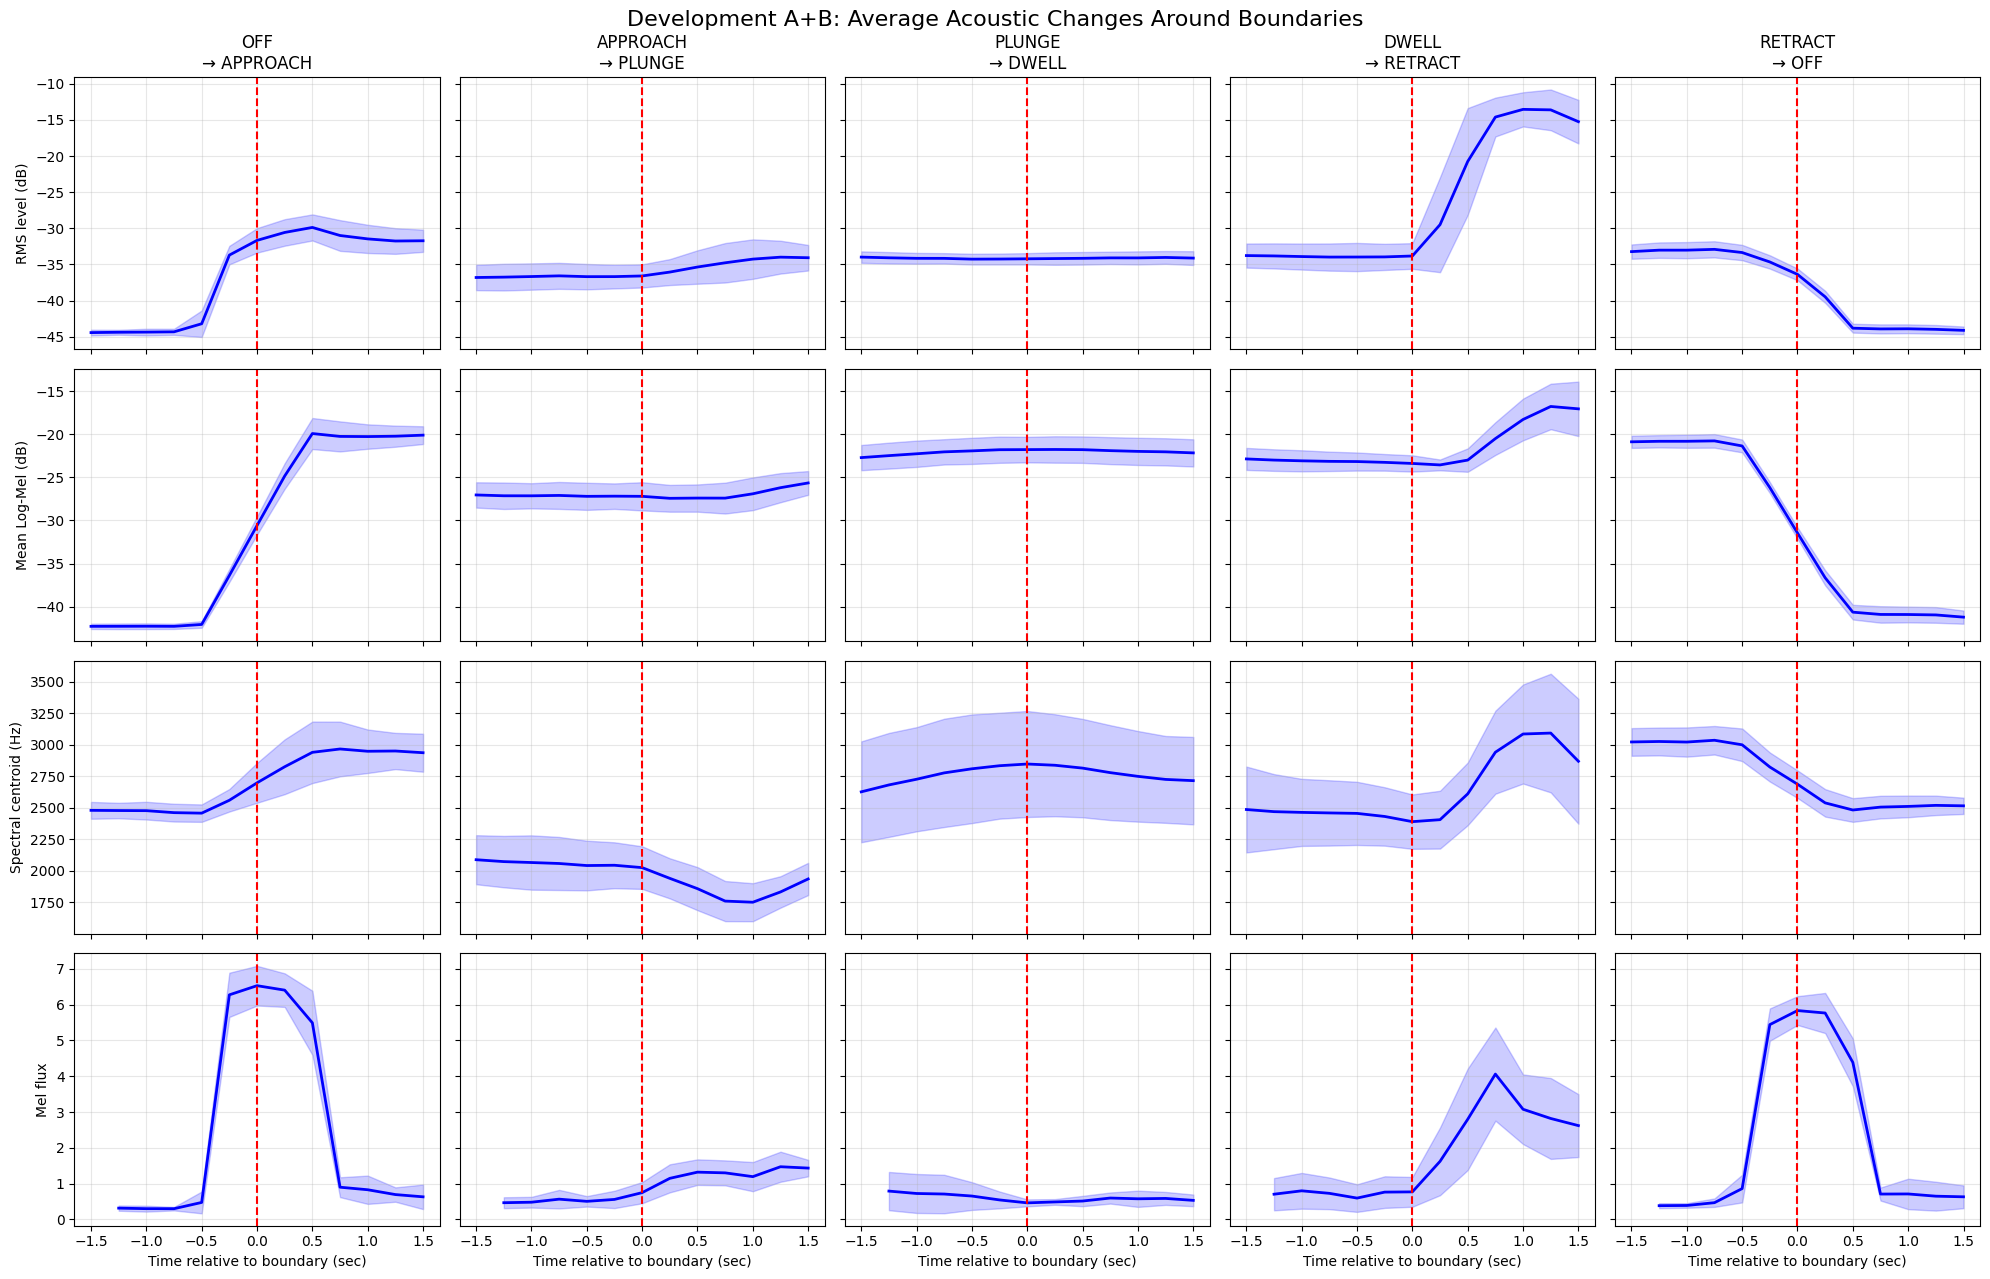

In [18]:
feature_columns = [
    (
        "rms_db",
        "RMS level (dB)",
    ),
    (
        "mean_log_mel_db",
        "Mean Log-Mel (dB)",
    ),
    (
        "spectral_centroid_hz",
        "Spectral centroid (Hz)",
    ),
    (
        "mel_flux_db",
        "Mel flux",
    ),
]

transition_order = [
    ("off", "approach"),
    ("approach", "plunge"),
    ("plunge", "dwell"),
    ("dwell", "retract"),
    ("retract", "off"),
]

fig, axes = plt.subplots(
    len(feature_columns),
    len(transition_order),
    figsize=(20, 13),
    sharex=True,
    sharey="row",
)

for row_index, (
    feature_name,
    feature_label,
) in enumerate(feature_columns):
    for column_index, (
        from_stage,
        to_stage,
    ) in enumerate(transition_order):
        axis = axes[
            row_index,
            column_index,
        ]

        transition_data = (
            boundary_features[
                (
                    boundary_features[
                        "from_stage"
                    ] == from_stage
                )
                & (
                    boundary_features[
                        "to_stage"
                    ] == to_stage
                )
            ]
        )

        summary = (
            transition_data.groupby(
                "relative_center_sec"
            )[feature_name]
            .agg(
                ["mean", "std"]
            )
            .reset_index()
        )

        x_values = summary[
            "relative_center_sec"
        ].to_numpy()

        mean_values = summary[
            "mean"
        ].to_numpy()

        std_values = summary[
            "std"
        ].fillna(0).to_numpy()

        axis.plot(
            x_values,
            mean_values,
            color="blue",
            linewidth=2,
        )

        axis.fill_between(
            x_values,
            mean_values - std_values,
            mean_values + std_values,
            color="blue",
            alpha=0.2,
        )

        axis.axvline(
            0.0,
            color="red",
            linestyle="--",
            linewidth=1.5,
        )

        axis.grid(alpha=0.3)

        if row_index == 0:
            axis.set_title(
                f"{from_stage.upper()}\n"
                f"→ {to_stage.upper()}"
            )

        if column_index == 0:
            axis.set_ylabel(
                feature_label
            )

        if row_index == (
            len(feature_columns) - 1
        ):
            axis.set_xlabel(
                "Time relative to boundary (sec)"
            )

fig.suptitle(
    "Development A+B: Average Acoustic Changes Around Boundaries",
    fontsize=16,
)

plt.tight_layout()
plt.show()
plt.close(fig)

## 5-stage Log-Mel cache 생성

타임라인의 모든 1초 윈도우를 동일한 `(64, 90)` Log-Mel spectrogram으로 변환한다.

실험과 시간 순서를 유지한 채 다음 세 파일로 분리해 저장한다.

- `development_A_5stage_logmel.npz`
- `development_B_5stage_logmel.npz`
- `test_holdout_5stage_logmel.npz`

각 cache에는 Log-Mel, stage hard/soft label, 경계 label, 경계 위치와 시계열 구성에 필요한 실험 번호 및 윈도우 순서를 함께 저장한다.

In [19]:
FIVE_STAGE_MEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MEL_SHAPE = make_log_mel(
    np.zeros(
        AUDIO_WINDOW_FRAMES,
        dtype=np.float32,
    )
).shape

soft_target_columns = [
    "target_off",
    "target_approach",
    "target_plunge",
    "target_dwell",
    "target_retract",
]

print(
    "저장 폴더:",
    FIVE_STAGE_MEL_DIR,
)

print(
    "Log-Mel shape:",
    MEL_SHAPE,
)

저장 폴더: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram
Log-Mel shape: (64, 90)


## 분할별 Log-Mel 변환 및 저장

동일한 WAV 파일을 윈도우마다 다시 열지 않고 한 번만 읽은 뒤 해당 파일의 모든 윈도우를 변환한다.

윈도우 순서는 `experiment_id → window_index` 순으로 고정해 이후 GRU 시퀀스를 구성할 수 있도록 한다.

In [20]:
def build_and_save_5stage_cache(
    dataset_role,
):
    role_manifest = (
        timeline_manifest[
            timeline_manifest[
                "dataset_role"
            ] == dataset_role
        ]
        .sort_values(
            [
                "experiment_id",
                "window_index",
            ]
        )
        .reset_index(drop=True)
        .copy()
    )

    sample_count = len(
        role_manifest
    )

    X = np.empty(
        (
            sample_count,
            MEL_SHAPE[0],
            MEL_SHAPE[1],
            1,
        ),
        dtype=np.float32,
    )

    y_stage = role_manifest[
        "center_stage_id"
    ].to_numpy(
        dtype=np.int64
    )

    y_stage_soft = role_manifest[
        soft_target_columns
    ].to_numpy(
        dtype=np.float32
    )

    y_boundary = role_manifest[
        "boundary_present"
    ].to_numpy(
        dtype=np.float32
    )

    boundary_offset = (
        role_manifest[
            "boundary_offset_sec"
        ]
        .fillna(-1.0)
        .to_numpy(
            dtype=np.float32
        )
    )

    processed_count = 0

    for (
        relative_path,
        file_rows,
    ) in role_manifest.groupby(
        "relative_path",
        sort=False,
    ):
        audio_path = (
            PROJECT_DIR / relative_path
        )

        full_audio, sample_rate = sf.read(
            str(audio_path),
            dtype="float32",
            always_2d=False,
        )

        if full_audio.ndim == 2:
            full_audio = (
                full_audio.mean(axis=1)
            )

        if sample_rate != SAMPLE_RATE:
            raise ValueError(
                f"샘플링레이트 오류: "
                f"{audio_path.name}"
            )

        for row_index, row in (
            file_rows.iterrows()
        ):
            start_frame = int(
                round(
                    float(
                        row[
                            "window_start_sec"
                        ]
                    )
                    * SAMPLE_RATE
                )
            )

            end_frame = (
                start_frame
                + AUDIO_WINDOW_FRAMES
            )

            audio_window = full_audio[
                start_frame:end_frame
            ]

            if (
                len(audio_window)
                != AUDIO_WINDOW_FRAMES
            ):
                raise ValueError(
                    f"윈도우 길이 오류: "
                    f"{audio_path.name}, "
                    f"{row['window_start_sec']}초"
                )

            X[
                row_index,
                :,
                :,
                0,
            ] = make_log_mel(
                audio_window
            )

            processed_count += 1

        print(
            f"\r{dataset_role}: "
            f"{processed_count}/"
            f"{sample_count} 변환",
            end="",
        )

    print()

    output_path = (
        FIVE_STAGE_MEL_DIR
        / (
            f"{dataset_role}"
            "_5stage_logmel.npz"
        )
    )

    np.savez_compressed(
        output_path,
        X=X,
        y_stage=y_stage,
        y_stage_soft=y_stage_soft,
        y_boundary=y_boundary,
        boundary_offset=boundary_offset,
        timeline_window_id=(
            role_manifest[
                "timeline_window_id"
            ].astype(str).to_numpy()
        ),
        experiment_id=(
            role_manifest[
                "experiment_id"
            ].to_numpy(
                dtype=np.int64
            )
        ),
        window_index=(
            role_manifest[
                "window_index"
            ].to_numpy(
                dtype=np.int64
            )
        ),
        window_start_sec=(
            role_manifest[
                "window_start_sec"
            ].to_numpy(
                dtype=np.float32
            )
        ),
        center_stage=(
            role_manifest[
                "center_stage"
            ].astype(str).to_numpy()
        ),
        from_stage=(
            role_manifest[
                "from_stage"
            ].fillna("").astype(
                str
            ).to_numpy()
        ),
        to_stage=(
            role_manifest[
                "to_stage"
            ].fillna("").astype(
                str
            ).to_numpy()
        ),
    )

    stage_ids, stage_counts = np.unique(
        y_stage,
        return_counts=True,
    )

    stage_count_result = {
        ID_TO_STAGE[
            int(stage_id)
        ]: int(stage_count)
        for stage_id, stage_count
        in zip(
            stage_ids,
            stage_counts,
        )
    }

    print(
        "저장 완료:",
        output_path,
    )

    print(
        "X shape:",
        X.shape,
    )

    print(
        "Stage 개수:",
        stage_count_result,
    )

    print(
        "경계 윈도우:",
        int(y_boundary.sum()),
    )

    return output_path

## 세 데이터 분할의 cache 생성

development_A, development_B, test_holdout 순서로 변환한다. test_holdout은 저장만 하고 모델 구조 선택이나 성능 분석에는 사용하지 않는다.

In [21]:
saved_5stage_cache_paths = []

for dataset_role in [
    "development_A",
    "development_B",
    "test_holdout",
]:
    saved_path = (
        build_and_save_5stage_cache(
            dataset_role
        )
    )

    saved_5stage_cache_paths.append(
        saved_path
    )

development_A: 1752/1752 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram/development_A_5stage_logmel.npz
X shape: (1752, 64, 90, 1)
Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 690}
경계 윈도우: 171
development_B: 1754/1754 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram/development_B_5stage_logmel.npz
X shape: (1754, 64, 90, 1)
Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 692}
경계 윈도우: 171
test_holdout: 1754/1754 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram/test_holdout_5stage_logmel.npz
X shape: (1754, 64, 90, 1)
Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 692}
경계 윈도우: 171


## PyTorch 환경과 개발 cache 불러오기

development_A와 development_B만 불러온다.

첫 번째 교차검증에서는 A를 학습 데이터로, B를 검증 데이터로 사용한다. test_holdout은 최종 모델이 결정될 때까지 불러오지 않는다.

In [22]:
import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "사용 장치:",
    device,
)

development_a_cache = np.load(
    FIVE_STAGE_MEL_DIR
    / "development_A_5stage_logmel.npz"
)

development_b_cache = np.load(
    FIVE_STAGE_MEL_DIR
    / "development_B_5stage_logmel.npz"
)

X_a = development_a_cache["X"]
y_stage_a = development_a_cache[
    "y_stage"
]
y_soft_a = development_a_cache[
    "y_stage_soft"
]
y_boundary_a = development_a_cache[
    "y_boundary"
]

X_b = development_b_cache["X"]
y_stage_b = development_b_cache[
    "y_stage"
]
y_soft_b = development_b_cache[
    "y_stage_soft"
]
y_boundary_b = development_b_cache[
    "y_boundary"
]

print(
    "development_A:",
    X_a.shape,
)

print(
    "development_B:",
    X_b.shape,
)

print(
    "A 경계 윈도우:",
    int(y_boundary_a.sum()),
)

print(
    "B 경계 윈도우:",
    int(y_boundary_b.sum()),
)

사용 장치: cuda
development_A: (1752, 64, 90, 1)
development_B: (1754, 64, 90, 1)
A 경계 윈도우: 171
B 경계 윈도우: 171


## 첫 번째 교차검증 정규화

학습 분할인 development_A에서만 전체 평균과 표준편차를 계산한다.

같은 값을 development_B에 적용해 검증 데이터의 통계정보가 학습에 유입되지 않도록 한다.

In [23]:
train_mean_fold_1 = X_a.mean(
    dtype=np.float64
)

train_std_fold_1 = X_a.std(
    dtype=np.float64
)

X_train_fold_1 = (
    (
        X_a - train_mean_fold_1
    )
    / train_std_fold_1
).astype(np.float32)

X_valid_fold_1 = (
    (
        X_b - train_mean_fold_1
    )
    / train_std_fold_1
).astype(np.float32)

print(
    "학습 평균:",
    train_mean_fold_1,
)

print(
    "학습 표준편차:",
    train_std_fold_1,
)

print(
    "정규화 후 평균:",
    X_train_fold_1.mean(),
)

print(
    "정규화 후 표준편차:",
    X_train_fold_1.std(),
)

학습 평균: -24.215343295948387
학습 표준편차: 15.584174597557935
정규화 후 평균: 6.9674835e-09
정규화 후 표준편차: 1.0000001


## 클래스 가중치 계산

OFF, Plunge와 Dwell은 Approach 및 Retract보다 윈도우 수가 적다.

학습 데이터 A의 hard label 개수로 클래스 가중치를 계산해 적은 stage의 오분류가 학습 손실에 더 크게 반영되도록 한다.

In [24]:
stage_counts_fold_1 = np.bincount(
    y_stage_a,
    minlength=5,
)

class_weights_fold_1 = (
    len(y_stage_a)
    / (
        5.0
        * stage_counts_fold_1
    )
).astype(np.float32)

print(
    "Stage 개수:",
    {
        ID_TO_STAGE[index]: int(count)
        for index, count
        in enumerate(
            stage_counts_fold_1
        )
    },
)

print(
    "클래스 가중치:",
    {
        ID_TO_STAGE[index]: float(weight)
        for index, weight
        in enumerate(
            class_weights_fold_1
        )
    },
)

Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 690}
클래스 가중치: {'off': 3.2444443702697754, 'approach': 0.7633987069129944, 'plunge': 1.4419753551483154, 'dwell': 1.3904762268066406, 'retract': 0.5078260898590088}


## PyTorch Tensor와 DataLoader 구성

PyTorch CNN 입력 형식에 맞게 `(N, 64, 90, 1)`을 `(N, 1, 64, 90)`으로 변경한다.

hard label은 평가에 사용하고, stage 포함 비율인 soft label은 학습 손실 계산에 사용한다.

In [25]:
def make_stage_dataset(
    X,
    y_stage,
    y_soft,
    y_boundary,
):
    X_tensor = torch.from_numpy(
        X
    ).permute(
        0, 3, 1, 2
    )

    y_stage_tensor = torch.from_numpy(
        y_stage
    ).long()

    y_soft_tensor = torch.from_numpy(
        y_soft
    ).float()

    y_boundary_tensor = torch.from_numpy(
        y_boundary
    ).float()

    return TensorDataset(
        X_tensor,
        y_stage_tensor,
        y_soft_tensor,
        y_boundary_tensor,
    )


train_dataset_fold_1 = (
    make_stage_dataset(
        X_train_fold_1,
        y_stage_a,
        y_soft_a,
        y_boundary_a,
    )
)

valid_dataset_fold_1 = (
    make_stage_dataset(
        X_valid_fold_1,
        y_stage_b,
        y_soft_b,
        y_boundary_b,
    )
)

train_loader_fold_1 = DataLoader(
    train_dataset_fold_1,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=(
        device.type == "cuda"
    ),
)

valid_loader_fold_1 = DataLoader(
    valid_dataset_fold_1,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=(
        device.type == "cuda"
    ),
)

print(
    "학습 Tensor:",
    train_dataset_fold_1.tensors[0].shape,
)

print(
    "검증 Tensor:",
    valid_dataset_fold_1.tensors[0].shape,
)

학습 Tensor: torch.Size([1752, 1, 64, 90])
검증 Tensor: torch.Size([1754, 1, 64, 90])


## 5-stage 기준 CNN 정의

각 1초 Log-Mel을 독립적으로 입력받아 다섯 stage 점수를 출력한다.

이 모델은 윈도우 사이의 시간 순서를 사용하지 않으며, 이후 CNN+GRU 모델의 개선 효과를 비교하기 위한 기준 모델이다.

In [26]:
import copy

import torch.nn.functional as F

from sklearn.metrics import (
    f1_score,
)


class FiveStageCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            64,
            5,
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(
            x,
            start_dim=1,
        )
        x = self.dropout(x)
        logits = self.classifier(x)

        return logits


torch.manual_seed(42)

model_cnn_fold_1 = (
    FiveStageCNN().to(device)
)

parameter_count = sum(
    parameter.numel()
    for parameter
    in model_cnn_fold_1.parameters()
    if parameter.requires_grad
)

print(model_cnn_fold_1)

print(
    "학습 가능 파라미터:",
    parameter_count,
)

FiveStageCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)
학습 가능 파라미터: 23845


## 클래스 가중 Soft-label 손실 함수

순수 윈도우에는 one-hot label을, 경계 혼합 윈도우에는 stage 포함 비율을 정답으로 사용한다.

학습 데이터에서 적은 stage가 무시되지 않도록 development_A에서 계산한 클래스 가중치를 적용한다.

In [27]:
class_weight_tensor_fold_1 = (
    torch.tensor(
        class_weights_fold_1,
        dtype=torch.float32,
        device=device,
    )
)


def weighted_soft_cross_entropy(
    logits,
    soft_targets,
    class_weights,
):
    log_probabilities = (
        F.log_softmax(
            logits,
            dim=1,
        )
    )

    weighted_targets = (
        soft_targets
        * class_weights.unsqueeze(0)
    )

    sample_losses = -(
        weighted_targets
        * log_probabilities
    ).sum(dim=1)

    return sample_losses.mean()

## CNN 학습 및 평가 함수

전체 stage 정확도와 Macro F1을 계산한다.

경계를 포함하지 않는 순수 윈도우와 경계를 포함하는 혼합 윈도우의 stage 정확도를 별도로 측정해 모델이 경계에서 얼마나 약해지는지 확인한다.

In [28]:
def run_cnn_stage_epoch(
    model,
    data_loader,
    class_weights,
    optimizer=None,
):
    is_training = (
        optimizer is not None
    )

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []
    all_boundary_flags = []

    for (
        batch_X,
        batch_hard_labels,
        batch_soft_labels,
        batch_boundary_flags,
    ) in data_loader:
        batch_X = batch_X.to(
            device,
            non_blocking=True,
        )

        batch_hard_labels = (
            batch_hard_labels.to(
                device,
                non_blocking=True,
            )
        )

        batch_soft_labels = (
            batch_soft_labels.to(
                device,
                non_blocking=True,
            )
        )

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            is_training
        ):
            logits = model(batch_X)

            loss = (
                weighted_soft_cross_entropy(
                    logits,
                    batch_soft_labels,
                    class_weights,
                )
            )

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(
            dim=1
        )

        total_loss += (
            loss.item()
            * batch_X.size(0)
        )

        all_labels.extend(
            batch_hard_labels
            .detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )

        all_boundary_flags.extend(
            batch_boundary_flags
            .numpy()
        )

    labels = np.asarray(
        all_labels
    )

    predictions = np.asarray(
        all_predictions
    )

    boundary_flags = (
        np.asarray(
            all_boundary_flags
        ).astype(bool)
    )

    accuracy = np.mean(
        labels == predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
    )

    interior_mask = (
        ~boundary_flags
    )

    boundary_accuracy = np.mean(
        labels[boundary_flags]
        == predictions[boundary_flags]
    )

    interior_accuracy = np.mean(
        labels[interior_mask]
        == predictions[interior_mask]
    )

    return {
        "loss": (
            total_loss
            / len(data_loader.dataset)
        ),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "interior_accuracy": (
            interior_accuracy
        ),
        "boundary_accuracy": (
            boundary_accuracy
        ),
    }

## 첫 번째 CNN 교차검증 학습

development_A로 학습하고 development_B로 검증한다.

검증 손실이 개선되지 않으면 학습률을 낮추고, 6회 연속 개선되지 않으면 학습을 중단한 뒤 가장 좋은 모델을 복원한다.

In [29]:
optimizer_cnn_fold_1 = (
    torch.optim.Adam(
        model_cnn_fold_1.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )
)

scheduler_cnn_fold_1 = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer_cnn_fold_1,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )
)

history_cnn_fold_1 = {
    "train_loss": [],
    "valid_loss": [],
    "train_accuracy": [],
    "valid_accuracy": [],
    "valid_macro_f1": [],
    "valid_interior_accuracy": [],
    "valid_boundary_accuracy": [],
}

best_valid_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 6

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    train_metrics = (
        run_cnn_stage_epoch(
            model_cnn_fold_1,
            train_loader_fold_1,
            class_weight_tensor_fold_1,
            optimizer_cnn_fold_1,
        )
    )

    valid_metrics = (
        run_cnn_stage_epoch(
            model_cnn_fold_1,
            valid_loader_fold_1,
            class_weight_tensor_fold_1,
        )
    )

    scheduler_cnn_fold_1.step(
        valid_metrics["loss"]
    )

    history_cnn_fold_1[
        "train_loss"
    ].append(
        train_metrics["loss"]
    )

    history_cnn_fold_1[
        "valid_loss"
    ].append(
        valid_metrics["loss"]
    )

    history_cnn_fold_1[
        "train_accuracy"
    ].append(
        train_metrics["accuracy"]
    )

    history_cnn_fold_1[
        "valid_accuracy"
    ].append(
        valid_metrics["accuracy"]
    )

    history_cnn_fold_1[
        "valid_macro_f1"
    ].append(
        valid_metrics["macro_f1"]
    )

    history_cnn_fold_1[
        "valid_interior_accuracy"
    ].append(
        valid_metrics[
            "interior_accuracy"
        ]
    )

    history_cnn_fold_1[
        "valid_boundary_accuracy"
    ].append(
        valid_metrics[
            "boundary_accuracy"
        ]
    )

    current_lr = (
        optimizer_cnn_fold_1
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_metrics['loss']:.4f} | "
        f"train acc "
        f"{train_metrics['accuracy']:.4f} | "
        f"val loss "
        f"{valid_metrics['loss']:.4f} | "
        f"val acc "
        f"{valid_metrics['accuracy']:.4f} | "
        f"macro F1 "
        f"{valid_metrics['macro_f1']:.4f} | "
        f"interior "
        f"{valid_metrics['interior_accuracy']:.4f} | "
        f"boundary "
        f"{valid_metrics['boundary_accuracy']:.4f} | "
        f"lr {current_lr:.1e}"
    )

    if (
        valid_metrics["loss"]
        < best_valid_loss - 1e-6
    ):
        best_valid_loss = (
            valid_metrics["loss"]
        )

        best_model_state = copy.deepcopy(
            model_cnn_fold_1.state_dict()
        )

        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "Early stopping:",
            epoch,
        )
        break

model_cnn_fold_1.load_state_dict(
    best_model_state
)

print(
    "최저 검증 손실:",
    round(
        best_valid_loss,
        6,
    ),
)

Epoch 01 | train loss 1.1401 | train acc 0.4521 | val loss 1.2390 | val acc 0.4829 | macro F1 0.3571 | interior 0.4991 | boundary 0.3333 | lr 1.0e-03
Epoch 02 | train loss 0.7697 | train acc 0.6815 | val loss 1.0710 | val acc 0.5422 | macro F1 0.5181 | interior 0.5660 | boundary 0.3216 | lr 1.0e-03
Epoch 03 | train loss 0.5729 | train acc 0.7631 | val loss 1.0397 | val acc 0.5621 | macro F1 0.5106 | interior 0.5850 | boundary 0.3509 | lr 1.0e-03
Epoch 04 | train loss 0.4732 | train acc 0.8373 | val loss 0.8962 | val acc 0.6129 | macro F1 0.5993 | interior 0.6418 | boundary 0.3450 | lr 1.0e-03
Epoch 05 | train loss 0.4050 | train acc 0.8670 | val loss 1.0762 | val acc 0.5656 | macro F1 0.5105 | interior 0.5875 | boundary 0.3626 | lr 1.0e-03
Epoch 06 | train loss 0.3633 | train acc 0.8801 | val loss 0.8790 | val acc 0.7041 | macro F1 0.6852 | interior 0.7397 | boundary 0.3743 | lr 1.0e-03
Epoch 07 | train loss 0.3160 | train acc 0.8973 | val loss 0.9159 | val acc 0.5673 | macro F1 0.5256

## CNN 기준 모델의 stage별 성능 분석

현재 CNN 모델이 어떤 공정 단계를 잘 구분하고, 어떤 단계끼리 혼동하는지 확인한다.

`development_A`로 학습하고 `development_B`로 검증한 최적 모델을 사용한다. 아직 GRU는 적용하지 않았으므로 각 1초 윈도우는 서로 독립적으로 분류된다.

다음 결과를 확인한다.

- **Precision**: 특정 stage라고 예측한 결과 중 실제로 해당 stage였던 비율
- **Recall**: 실제 특정 stage 윈도우 중 모델이 올바르게 찾아낸 비율
- **F1-score**: Precision과 Recall을 함께 반영한 점수
- **Confusion Matrix**: 실제 stage가 어떤 다른 stage로 잘못 분류됐는지 나타낸 행렬

왼쪽 혼동행렬은 윈도우 개수를 나타내고, 오른쪽 혼동행렬은 각 실제 stage를 기준으로 정규화한 비율을 나타낸다.

이 결과는 CNN+GRU 모델을 적용하기 전 CNN 기준 성능으로 사용한다.

Development B 전체 검증 결과

              precision    recall  f1-score   support

         OFF     0.8244    1.0000    0.9038       108
    APPROACH     0.8819    0.7320    0.8000       459
      PLUNGE     0.8703    0.6626    0.7523       243
       DWELL     0.9012    0.2897    0.4384       252
     RETRACT     0.6363    0.8974    0.7446       692

    accuracy                         0.7406      1754
   macro avg     0.8228    0.7163    0.7278      1754
weighted avg     0.7826    0.7406    0.7260      1754



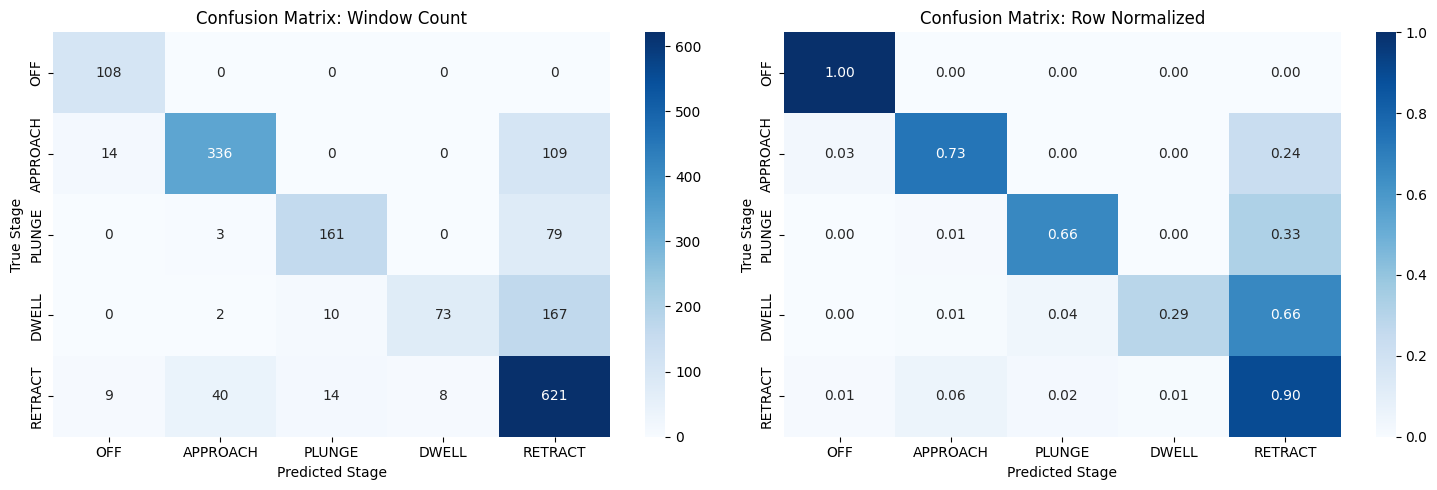

In [33]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import seaborn as sns

stage_names = [
    "OFF",
    "APPROACH",
    "PLUNGE",
    "DWELL",
    "RETRACT"
]

model_cnn_fold_1.eval()

all_true = []
all_pred = []
all_boundary = []

with torch.no_grad():
    for (
        batch_X,
        batch_hard_labels,
        batch_soft_labels,
        batch_boundary_flags
    ) in valid_loader_fold_1:

        batch_X = batch_X.to(device)

        logits = model_cnn_fold_1(
            batch_X
        )

        predictions = logits.argmax(
            dim=1
        )

        all_true.extend(
            batch_hard_labels.numpy()
        )

        all_pred.extend(
            predictions
            .cpu()
            .numpy()
        )

        all_boundary.extend(
            batch_boundary_flags.numpy()
        )

all_true = np.asarray(
    all_true
)

all_pred = np.asarray(
    all_pred
)

all_boundary = np.asarray(
    all_boundary
).astype(bool)

print(
    "Development B 전체 검증 결과\n"
)

print(
    classification_report(
        all_true,
        all_pred,
        labels=range(5),
        target_names=stage_names,
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(
    all_true,
    all_pred,
    labels=range(5)
)

cm_normalized = confusion_matrix(
    all_true,
    all_pred,
    labels=range(5),
    normalize="true"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=stage_names,
    yticklabels=stage_names,
    ax=axes[0]
)

axes[0].set_title(
    "Confusion Matrix: Window Count"
)
axes[0].set_xlabel(
    "Predicted Stage"
)
axes[0].set_ylabel(
    "True Stage"
)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=stage_names,
    yticklabels=stage_names,
    ax=axes[1]
)

axes[1].set_title(
    "Confusion Matrix: Row Normalized"
)
axes[1].set_xlabel(
    "Predicted Stage"
)
axes[1].set_ylabel(
    "True Stage"
)

plt.tight_layout()
plt.show()

## CNN-GRU용 연속 윈도우 시퀀스 구성

CNN 기준 모델은 각각의 1초 Log-Mel 윈도우를 독립적으로 분류했기 때문에 공정 단계가 변화해 온 흐름을 알 수 없었다.

GRU 입력을 만들기 위해 동일한 실험에서 시간순으로 연속된 8개 윈도우를 하나의 시퀀스로 구성한다.

- 각 윈도우 길이: 1초
- 윈도우 간격: 0.25초
- 시퀀스 길이: 8개
- 전체 시간 범위: 2.75초
- 예측 대상: 시퀀스의 마지막 윈도우
- 입력 방향: 과거에서 현재 방향
- 서로 다른 실험의 윈도우는 하나의 시퀀스로 연결하지 않음

Stage 정답은 마지막 윈도우의 soft label과 center-stage label을 사용한다. 경계 정답 역시 마지막 윈도우의 boundary label을 사용한다.

정규화 평균과 표준편차는 development_A에서만 계산하고 development_B에 동일하게 적용하여 데이터 누수를 방지한다.

In [34]:
SEQUENCE_LENGTH = 8

development_a_cache_path = (
    FIVE_STAGE_MEL_DIR
    / "development_A_5stage_logmel.npz"
)

development_b_cache_path = (
    FIVE_STAGE_MEL_DIR
    / "development_B_5stage_logmel.npz"
)

cache_a = np.load(
    development_a_cache_path,
    allow_pickle=True
)

cache_b = np.load(
    development_b_cache_path,
    allow_pickle=True
)

X_gru_a = cache_a["X"].astype(
    np.float32
)

X_gru_b = cache_b["X"].astype(
    np.float32
)

y_stage_a = cache_a["y_stage"].astype(
    np.int64
)

y_stage_b = cache_b["y_stage"].astype(
    np.int64
)

y_stage_soft_a = cache_a[
    "y_stage_soft"
].astype(np.float32)

y_stage_soft_b = cache_b[
    "y_stage_soft"
].astype(np.float32)

y_boundary_a = cache_a[
    "y_boundary"
].astype(np.float32)

y_boundary_b = cache_b[
    "y_boundary"
].astype(np.float32)

experiment_id_a = cache_a[
    "experiment_id"
].astype(np.int64)

experiment_id_b = cache_b[
    "experiment_id"
].astype(np.int64)

window_index_a = cache_a[
    "window_index"
].astype(np.int64)

window_index_b = cache_b[
    "window_index"
].astype(np.int64)

train_mean_gru = X_gru_a.mean(
    dtype=np.float64
)

train_std_gru = X_gru_a.std(
    dtype=np.float64
)

if train_std_gru == 0:
    raise ValueError(
        "학습 데이터의 표준편차가 0입니다."
    )

X_gru_a = (
    (X_gru_a - train_mean_gru)
    / train_std_gru
).astype(np.float32)

X_gru_b = (
    (X_gru_b - train_mean_gru)
    / train_std_gru
).astype(np.float32)

print(
    "GRU 학습 평균:",
    train_mean_gru
)

print(
    "GRU 학습 표준편차:",
    train_std_gru
)

print(
    "정규화 후 development_A 평균:",
    X_gru_a.mean()
)

print(
    "정규화 후 development_A 표준편차:",
    X_gru_a.std()
)

GRU 학습 평균: -24.215343295948387
GRU 학습 표준편차: 15.584174597557935
정규화 후 development_A 평균: 6.9674835e-09
정규화 후 development_A 표준편차: 1.0000001


### 실험별 시퀀스 시작 위치 생성

각 실험의 윈도우를 `window_index` 기준으로 정렬한 뒤 연속된 8개 윈도우의 위치를 생성한다.

다음 조건을 모두 만족하는 시퀀스만 사용한다.

- 8개 윈도우가 모두 같은 실험에 속함
- `window_index`가 1씩 연속해서 증가함
- 시퀀스의 마지막 윈도우를 정답 대상으로 사용함

이 검사를 통해 이전 실험의 Retract/OFF 구간과 다음 실험의 OFF/Approach 구간이 잘못 연결되는 것을 방지한다.

In [35]:
def build_sequence_indices(
    experiment_ids,
    window_indices,
    sequence_length
):
    sequence_indices = []

    unique_experiments = np.unique(
        experiment_ids
    )

    for experiment_id in unique_experiments:
        experiment_positions = np.where(
            experiment_ids == experiment_id
        )[0]

        sorted_order = np.argsort(
            window_indices[
                experiment_positions
            ]
        )

        experiment_positions = (
            experiment_positions[
                sorted_order
            ]
        )

        experiment_window_indices = (
            window_indices[
                experiment_positions
            ]
        )

        for start_position in range(
            len(experiment_positions)
            - sequence_length
            + 1
        ):
            selected_positions = (
                experiment_positions[
                    start_position:
                    start_position
                    + sequence_length
                ]
            )

            selected_window_indices = (
                experiment_window_indices[
                    start_position:
                    start_position
                    + sequence_length
                ]
            )

            expected_window_indices = (
                np.arange(
                    selected_window_indices[0],
                    selected_window_indices[0]
                    + sequence_length
                )
            )

            if np.array_equal(
                selected_window_indices,
                expected_window_indices
            ):
                sequence_indices.append(
                    selected_positions
                )

    return np.asarray(
        sequence_indices,
        dtype=np.int64
    )


sequence_indices_a = (
    build_sequence_indices(
        experiment_id_a,
        window_index_a,
        SEQUENCE_LENGTH
    )
)

sequence_indices_b = (
    build_sequence_indices(
        experiment_id_b,
        window_index_b,
        SEQUENCE_LENGTH
    )
)

print(
    "development_A 시퀀스 수:",
    len(sequence_indices_a)
)

print(
    "development_B 시퀀스 수:",
    len(sequence_indices_b)
)

print(
    "시퀀스 index shape:",
    sequence_indices_a.shape
)

print(
    "첫 번째 시퀀스의 window index:",
    window_index_a[
        sequence_indices_a[0]
    ]
)

print(
    "첫 번째 시퀀스의 experiment ID:",
    experiment_id_a[
        sequence_indices_a[0]
    ]
)

train_cross_experiment_count = sum(
    len(
        np.unique(
            experiment_id_a[
                sequence_positions
            ]
        )
    ) != 1
    for sequence_positions
    in sequence_indices_a
)

valid_cross_experiment_count = sum(
    len(
        np.unique(
            experiment_id_b[
                sequence_positions
            ]
        )
    ) != 1
    for sequence_positions
    in sequence_indices_b
)

print(
    "학습 실험 경계 침범:",
    train_cross_experiment_count
)

print(
    "검증 실험 경계 침범:",
    valid_cross_experiment_count
)

development_A 시퀀스 수: 1689
development_B 시퀀스 수: 1691
시퀀스 index shape: (1689, 8)
첫 번째 시퀀스의 window index: [0 1 2 3 4 5 6 7]
첫 번째 시퀀스의 experiment ID: [1 1 1 1 1 1 1 1]
학습 실험 경계 침범: 0
검증 실험 경계 침범: 0


## CNN-GRU Dataset과 DataLoader 구성

연속된 8개의 Log-Mel 윈도우를 하나의 입력 시퀀스로 반환하는 PyTorch Dataset을 구성한다.

하나의 학습 데이터는 다음과 같이 구성된다.

- 입력: 연속된 Log-Mel 8개
- 입력 크기: `(8, 1, 64, 90)`
- hard stage label: 마지막 윈도우 중심 시점의 stage
- soft stage label: 마지막 윈도우에 포함된 각 stage의 비율
- boundary label: 마지막 윈도우가 경계를 포함하는지 여부

전체 시퀀스 음향을 새로운 배열로 복사하지 않고 원본 Log-Mel 배열과 시퀀스 위치만 보관하여 메모리 사용량을 줄인다.

클래스 불균형을 보정하기 위해 development_A의 마지막 윈도우 라벨을 기준으로 stage class weight와 boundary positive weight를 계산한다.

In [36]:
from torch.utils.data import (
    Dataset,
    DataLoader
)

class FSSWSequenceDataset(Dataset):
    def __init__(
        self,
        X,
        hard_labels,
        soft_labels,
        boundary_labels,
        sequence_indices
    ):
        self.X = X
        self.hard_labels = hard_labels
        self.soft_labels = soft_labels
        self.boundary_labels = boundary_labels
        self.sequence_indices = (
            sequence_indices
        )

    def __len__(self):
        return len(
            self.sequence_indices
        )

    def __getitem__(self, index):
        selected_indices = (
            self.sequence_indices[index]
        )

        target_index = (
            selected_indices[-1]
        )

        sequence_X = self.X[
            selected_indices
        ]

        sequence_X = torch.from_numpy(
            sequence_X
        ).permute(
            0,
            3,
            1,
            2
        )

        hard_label = torch.tensor(
            self.hard_labels[target_index],
            dtype=torch.long
        )

        soft_label = torch.from_numpy(
            self.soft_labels[target_index]
        ).float()

        boundary_label = torch.tensor(
            self.boundary_labels[
                target_index
            ],
            dtype=torch.float32
        )

        return (
            sequence_X,
            hard_label,
            soft_label,
            boundary_label
        )


train_sequence_dataset = (
    FSSWSequenceDataset(
        X_gru_a,
        y_stage_a,
        y_stage_soft_a,
        y_boundary_a,
        sequence_indices_a
    )
)

valid_sequence_dataset = (
    FSSWSequenceDataset(
        X_gru_b,
        y_stage_b,
        y_stage_soft_b,
        y_boundary_b,
        sequence_indices_b
    )
)

BATCH_SIZE_GRU = 16

train_sequence_loader = DataLoader(
    train_sequence_dataset,
    batch_size=BATCH_SIZE_GRU,
    shuffle=True,
    num_workers=2,
    pin_memory=(
        device.type == "cuda"
    )
)

valid_sequence_loader = DataLoader(
    valid_sequence_dataset,
    batch_size=BATCH_SIZE_GRU,
    shuffle=False,
    num_workers=2,
    pin_memory=(
        device.type == "cuda"
    )
)

train_target_indices = (
    sequence_indices_a[:, -1]
)

train_target_labels = y_stage_a[
    train_target_indices
]

stage_counts_gru = np.bincount(
    train_target_labels,
    minlength=5
)

stage_class_weights_gru = (
    len(train_target_labels)
    / (
        5
        * stage_counts_gru
    )
).astype(np.float32)

train_boundary_targets = (
    y_boundary_a[
        train_target_indices
    ]
)

boundary_positive_count = (
    train_boundary_targets.sum()
)

boundary_negative_count = (
    len(train_boundary_targets)
    - boundary_positive_count
)

boundary_positive_weight = (
    boundary_negative_count
    / boundary_positive_count
)

stage_class_weight_tensor_gru = (
    torch.tensor(
        stage_class_weights_gru,
        dtype=torch.float32,
        device=device
    )
)

boundary_positive_weight_tensor = (
    torch.tensor(
        boundary_positive_weight,
        dtype=torch.float32,
        device=device
    )
)

sample_batch = next(
    iter(train_sequence_loader)
)

print(
    "학습 시퀀스 수:",
    len(train_sequence_dataset)
)

print(
    "검증 시퀀스 수:",
    len(valid_sequence_dataset)
)

print(
    "입력 batch shape:",
    sample_batch[0].shape
)

print(
    "hard label shape:",
    sample_batch[1].shape
)

print(
    "soft label shape:",
    sample_batch[2].shape
)

print(
    "boundary label shape:",
    sample_batch[3].shape
)

print(
    "Stage별 학습 표본 수:",
    dict(
        zip(
            stage_names,
            stage_counts_gru
        )
    )
)

print(
    "Stage class weight:",
    stage_class_weights_gru
)

print(
    "Boundary positive weight:",
    float(
        boundary_positive_weight
    )
)

학습 시퀀스 수: 1689
검증 시퀀스 수: 1691
입력 batch shape: torch.Size([16, 8, 1, 64, 90])
hard label shape: torch.Size([16])
soft label shape: torch.Size([16, 5])
boundary label shape: torch.Size([16])
Stage별 학습 표본 수: {'OFF': np.int64(54), 'APPROACH': np.int64(450), 'PLUNGE': np.int64(243), 'DWELL': np.int64(252), 'RETRACT': np.int64(690)}
Stage class weight: [6.2555556  0.7506667  1.3901235  1.3404762  0.48956522]
Boundary positive weight: 10.039216041564941


## CNN-GRU stage 및 boundary 모델 구성

각 시점의 Log-Mel 스펙트로그램에서 CNN이 음향 특징을 추출하고, GRU가 최근 8개 윈도우에서 특징이 변화한 흐름을 분석한다.

모델 구조는 다음과 같다.

1. **CNN encoder**
   - 각각의 1초 Log-Mel에서 주파수 및 시간 패턴 추출
   - 각 윈도우를 하나의 특징 벡터로 변환

2. **단방향 GRU**
   - 과거에서 현재 방향으로 CNN 특징을 처리
   - 미래 윈도우를 사용하지 않음
   - 마지막 시점의 GRU 출력을 현재 상태 표현으로 사용

3. **Stage head**
   - 마지막 윈도우의 OFF, Approach, Plunge, Dwell, Retract 분류

4. **Boundary head**
   - 마지막 윈도우가 두 stage의 경계를 포함하는지 이진 분류

Stage와 boundary를 함께 학습함으로써 모델이 현재 음향의 종류뿐 아니라 공정 전환이 발생하고 있는지도 학습하도록 한다.

In [37]:
class CNNGRUStageBoundaryModel(nn.Module):
    def __init__(
        self,
        number_of_stages=5,
        cnn_feature_size=128,
        gru_hidden_size=128
    ):
        super().__init__()

        self.cnn_encoder = nn.Sequential(
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.cnn_projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64,
                cnn_feature_size
            ),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.gru = nn.GRU(
            input_size=cnn_feature_size,
            hidden_size=gru_hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.shared_layer = nn.Sequential(
            nn.Linear(
                gru_hidden_size,
                64
            ),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.stage_head = nn.Linear(
            64,
            number_of_stages
        )

        self.boundary_head = nn.Linear(
            64,
            1
        )

    def forward(self, sequence_X):
        batch_size = sequence_X.size(0)
        sequence_length = sequence_X.size(1)

        flattened_X = sequence_X.reshape(
            batch_size * sequence_length,
            sequence_X.size(2),
            sequence_X.size(3),
            sequence_X.size(4)
        )

        cnn_features = self.cnn_encoder(
            flattened_X
        )

        cnn_features = self.cnn_projection(
            cnn_features
        )

        cnn_features = cnn_features.reshape(
            batch_size,
            sequence_length,
            -1
        )

        gru_output, _ = self.gru(
            cnn_features
        )

        current_time_feature = (
            gru_output[:, -1, :]
        )

        shared_feature = self.shared_layer(
            current_time_feature
        )

        stage_logits = self.stage_head(
            shared_feature
        )

        boundary_logit = self.boundary_head(
            shared_feature
        ).squeeze(1)

        return (
            stage_logits,
            boundary_logit
        )


model_cnn_gru = (
    CNNGRUStageBoundaryModel()
    .to(device)
)

with torch.no_grad():
    sample_X = sample_batch[0].to(
        device
    )

    (
        sample_stage_logits,
        sample_boundary_logits
    ) = model_cnn_gru(sample_X)

print(
    model_cnn_gru
)

print(
    "\nStage 출력 shape:",
    sample_stage_logits.shape
)

print(
    "Boundary 출력 shape:",
    sample_boundary_logits.shape
)

CNNGRUStageBoundaryModel(
  (cnn_encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (cnn_projection): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=Fa

## CNN-GRU 다중 목표 손실함수 및 학습 함수

CNN-GRU 모델은 stage 분류와 boundary 검출을 동시에 학습한다.

### Stage loss

경계가 없는 윈도우는 하나의 stage만 정답이지만, 경계 윈도우에는 두 stage가 함께 포함된다. 따라서 hard label 대신 각 stage가 포함된 비율인 soft label을 이용해 stage loss를 계산한다.

데이터 수가 적은 OFF, Plunge, Dwell이 무시되지 않도록 development_A에서 계산한 stage class weight를 적용한다.

### Boundary loss

마지막 윈도우가 stage 경계를 포함하는지를 이진 분류한다. 경계 윈도우 수가 비경계 윈도우보다 적으므로 positive weight를 적용한 Binary Cross Entropy를 사용한다.

### 전체 손실

`전체 손실 = Stage loss + 0.5 × Boundary loss`

Stage 분류를 주목표로 유지하면서 boundary 정보도 CNN과 GRU 특징에 반영되도록 boundary loss에 0.5의 가중치를 적용한다.

검증 과정에서는 다음 성능을 측정한다.

- 전체 stage 정확도
- Stage Macro F1
- 순수 stage 내부 윈도우 정확도
- 경계 포함 윈도우의 stage 정확도
- Boundary Precision
- Boundary Recall
- Boundary F1

In [43]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)

BOUNDARY_LOSS_WEIGHT = 0.2


def weighted_soft_stage_loss(
    stage_logits,
    soft_targets,
    class_weights
):
    log_probabilities = F.log_softmax(
        stage_logits,
        dim=1
    )

    weighted_targets = (
        soft_targets
        * class_weights.unsqueeze(0)
    )

    sample_weight_sums = (
        weighted_targets.sum(
            dim=1
        ).clamp_min(1e-8)
    )

    sample_losses = -(
        weighted_targets
        * log_probabilities
    ).sum(dim=1)

    sample_losses = (
        sample_losses
        / sample_weight_sums
    )

    return sample_losses.mean()


boundary_loss_function = (
    nn.BCEWithLogitsLoss(
        pos_weight=(
            boundary_positive_weight_tensor
        )
    )
)


def run_cnn_gru_epoch(
    model,
    data_loader,
    optimizer=None
):
    is_training = (
        optimizer is not None
    )

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_stage_loss = 0.0
    total_boundary_loss = 0.0

    all_stage_labels = []
    all_stage_predictions = []

    all_boundary_labels = []
    all_boundary_predictions = []

    for (
        batch_X,
        batch_hard_labels,
        batch_soft_labels,
        batch_boundary_labels
    ) in data_loader:

        batch_X = batch_X.to(
            device,
            non_blocking=True
        )

        batch_hard_labels = (
            batch_hard_labels.to(
                device,
                non_blocking=True
            )
        )

        batch_soft_labels = (
            batch_soft_labels.to(
                device,
                non_blocking=True
            )
        )

        batch_boundary_labels = (
            batch_boundary_labels.to(
                device,
                non_blocking=True
            )
        )

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            is_training
        ):
            (
                stage_logits,
                boundary_logits
            ) = model(batch_X)

            stage_loss = (
                weighted_soft_stage_loss(
                    stage_logits,
                    batch_soft_labels,
                    stage_class_weight_tensor_gru
                )
            )

            boundary_loss = (
                boundary_loss_function(
                    boundary_logits,
                    batch_boundary_labels
                )
            )

            loss = (
                stage_loss
                + BOUNDARY_LOSS_WEIGHT
                * boundary_loss
            )

            if is_training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0
                )

                optimizer.step()

        stage_predictions = (
            stage_logits.argmax(
                dim=1
            )
        )

        boundary_probabilities = (
            torch.sigmoid(
                boundary_logits
            )
        )

        boundary_predictions = (
            boundary_probabilities
            >= 0.5
        ).long()

        batch_size = batch_X.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        total_stage_loss += (
            stage_loss.item()
            * batch_size
        )

        total_boundary_loss += (
            boundary_loss.item()
            * batch_size
        )

        all_stage_labels.extend(
            batch_hard_labels
            .detach()
            .cpu()
            .numpy()
        )

        all_stage_predictions.extend(
            stage_predictions
            .detach()
            .cpu()
            .numpy()
        )

        all_boundary_labels.extend(
            batch_boundary_labels
            .detach()
            .cpu()
            .numpy()
        )

        all_boundary_predictions.extend(
            boundary_predictions
            .detach()
            .cpu()
            .numpy()
        )

    stage_labels = np.asarray(
        all_stage_labels
    )

    stage_predictions = np.asarray(
        all_stage_predictions
    )

    boundary_labels = np.asarray(
        all_boundary_labels
    ).astype(bool)

    boundary_predictions = np.asarray(
        all_boundary_predictions
    )

    interior_mask = (
        ~boundary_labels
    )

    stage_accuracy = np.mean(
        stage_labels
        == stage_predictions
    )

    stage_macro_f1 = f1_score(
        stage_labels,
        stage_predictions,
        average="macro",
        zero_division=0
    )

    interior_stage_accuracy = np.mean(
        stage_labels[interior_mask]
        == stage_predictions[interior_mask]
    )

    boundary_stage_accuracy = np.mean(
        stage_labels[boundary_labels]
        == stage_predictions[boundary_labels]
    )

    boundary_precision = precision_score(
        boundary_labels,
        boundary_predictions,
        zero_division=0
    )

    boundary_recall = recall_score(
        boundary_labels,
        boundary_predictions,
        zero_division=0
    )

    boundary_f1 = f1_score(
        boundary_labels,
        boundary_predictions,
        zero_division=0
    )

    dataset_size = len(
        data_loader.dataset
    )

    return {
        "loss": (
            total_loss
            / dataset_size
        ),
        "stage_loss": (
            total_stage_loss
            / dataset_size
        ),
        "boundary_loss": (
            total_boundary_loss
            / dataset_size
        ),
        "stage_accuracy": (
            stage_accuracy
        ),
        "stage_macro_f1": (
            stage_macro_f1
        ),
        "interior_stage_accuracy": (
            interior_stage_accuracy
        ),
        "boundary_stage_accuracy": (
            boundary_stage_accuracy
        ),
        "boundary_precision": (
            boundary_precision
        ),
        "boundary_recall": (
            boundary_recall
        ),
        "boundary_f1": (
            boundary_f1
        )
    }

## CNN-GRU 모델 학습

development_A 시퀀스로 CNN-GRU를 학습하고 development_B 시퀀스로 검증한다.

- Optimizer: Adam
- 초기 학습률: 0.005
- 최대 Epoch: 40
- Early stopping: 검증 손실이 7회 연속 개선되지 않으면 종료
- 학습률 감소: 검증 손실이 3회 동안 개선되지 않으면 절반으로 감소
- Gradient clipping: GRU의 gradient가 지나치게 커지는 현상을 방지

학습이 끝나면 검증 손실이 가장 낮았던 시점의 모델 가중치를 복원한다.

현재 결과는 기존 단일 윈도우 CNN 기준 모델과 비교한다.

- CNN 전체 정확도: 74.06%
- CNN Macro F1: 72.78%
- CNN 순수 내부 정확도: 77.26%
- CNN 경계 윈도우 stage 정확도: 44.44%

In [44]:
optimizer_cnn_gru = torch.optim.Adam(
    model_cnn_gru.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler_cnn_gru = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer_cnn_gru,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
)

history_cnn_gru = {
    "train_loss": [],
    "valid_loss": [],
    "valid_stage_accuracy": [],
    "valid_stage_macro_f1": [],
    "valid_interior_stage_accuracy": [],
    "valid_boundary_stage_accuracy": [],
    "valid_boundary_precision": [],
    "valid_boundary_recall": [],
    "valid_boundary_f1": []
}

best_valid_loss_cnn_gru = float(
    "inf"
)

best_model_state_cnn_gru = None

epochs_without_improvement = 0

MAX_EPOCHS_GRU = 40
EARLY_STOPPING_PATIENCE_GRU = 15

for epoch in range(
    1,
    MAX_EPOCHS_GRU + 1
):
    train_metrics_gru = (
        run_cnn_gru_epoch(
            model_cnn_gru,
            train_sequence_loader,
            optimizer_cnn_gru
        )
    )

    valid_metrics_gru = (
        run_cnn_gru_epoch(
            model_cnn_gru,
            valid_sequence_loader
        )
    )

    scheduler_cnn_gru.step(
        valid_metrics_gru["loss"]
    )

    history_cnn_gru[
        "train_loss"
    ].append(
        train_metrics_gru["loss"]
    )

    history_cnn_gru[
        "valid_loss"
    ].append(
        valid_metrics_gru["loss"]
    )

    history_cnn_gru[
        "valid_stage_accuracy"
    ].append(
        valid_metrics_gru[
            "stage_accuracy"
        ]
    )

    history_cnn_gru[
        "valid_stage_macro_f1"
    ].append(
        valid_metrics_gru[
            "stage_macro_f1"
        ]
    )

    history_cnn_gru[
        "valid_interior_stage_accuracy"
    ].append(
        valid_metrics_gru[
            "interior_stage_accuracy"
        ]
    )

    history_cnn_gru[
        "valid_boundary_stage_accuracy"
    ].append(
        valid_metrics_gru[
            "boundary_stage_accuracy"
        ]
    )

    history_cnn_gru[
        "valid_boundary_precision"
    ].append(
        valid_metrics_gru[
            "boundary_precision"
        ]
    )

    history_cnn_gru[
        "valid_boundary_recall"
    ].append(
        valid_metrics_gru[
            "boundary_recall"
        ]
    )

    history_cnn_gru[
        "valid_boundary_f1"
    ].append(
        valid_metrics_gru[
            "boundary_f1"
        ]
    )

    current_lr = (
        optimizer_cnn_gru
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_metrics_gru['loss']:.4f} | "
        f"val loss "
        f"{valid_metrics_gru['loss']:.4f} | "
        f"stage acc "
        f"{valid_metrics_gru['stage_accuracy']:.4f} | "
        f"macro F1 "
        f"{valid_metrics_gru['stage_macro_f1']:.4f} | "
        f"interior "
        f"{valid_metrics_gru['interior_stage_accuracy']:.4f} | "
        f"boundary-stage "
        f"{valid_metrics_gru['boundary_stage_accuracy']:.4f} | "
        f"boundary P/R/F1 "
        f"{valid_metrics_gru['boundary_precision']:.3f}/"
        f"{valid_metrics_gru['boundary_recall']:.3f}/"
        f"{valid_metrics_gru['boundary_f1']:.3f} | "
        f"lr {current_lr:.1e}"
    )

    if (
        valid_metrics_gru["loss"]
        < best_valid_loss_cnn_gru
        - 1e-6
    ):
        best_valid_loss_cnn_gru = (
            valid_metrics_gru["loss"]
        )

        best_model_state_cnn_gru = (
            copy.deepcopy(
                model_cnn_gru.state_dict()
            )
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE_GRU
    ):
        print(
            "Early stopping:",
            epoch
        )
        break

model_cnn_gru.load_state_dict(
    best_model_state_cnn_gru
)

print(
    "최저 검증 손실:",
    round(
        best_valid_loss_cnn_gru,
        6
    )
)

Epoch 01 | train loss 0.4981 | val loss 2.8696 | stage acc 0.4494 | macro F1 0.3793 | interior 0.4688 | boundary-stage 0.2549 | boundary P/R/F1 0.149/0.758/0.249 | lr 5.0e-04
Epoch 02 | train loss 0.4107 | val loss 2.9302 | stage acc 0.5240 | macro F1 0.4527 | interior 0.5462 | boundary-stage 0.3007 | boundary P/R/F1 0.251/0.529/0.340 | lr 5.0e-04
Epoch 03 | train loss 0.3531 | val loss 5.4269 | stage acc 0.5925 | macro F1 0.4080 | interior 0.6235 | boundary-stage 0.2810 | boundary P/R/F1 0.419/0.170/0.242 | lr 5.0e-04
Epoch 04 | train loss 0.3676 | val loss 4.7222 | stage acc 0.4483 | macro F1 0.3054 | interior 0.4623 | boundary-stage 0.3072 | boundary P/R/F1 0.431/0.307/0.359 | lr 5.0e-04
Epoch 05 | train loss 0.3583 | val loss 4.5484 | stage acc 0.5748 | macro F1 0.4391 | interior 0.6014 | boundary-stage 0.3072 | boundary P/R/F1 0.397/0.353/0.374 | lr 2.5e-04
Epoch 06 | train loss 0.2807 | val loss 6.1400 | stage acc 0.4465 | macro F1 0.3048 | interior 0.4610 | boundary-stage 0.3007

KeyboardInterrupt: 

## 학습된 CNN 특징 추출기를 이용한 단방향 GRU

기존 CNN-GRU 실험에서는 CNN과 GRU를 모두 무작위 가중치에서 새로 학습하여 development_A에 과적합이 발생했다.

이번 실험에서는 앞서 학습한 최적 CNN 모델의 특징 추출 부분을 복사하고 동결한다.

모델 구조는 다음과 같다.

1. 연속된 8개의 1초 Log-Mel 입력
2. 학습된 CNN이 각 윈도우를 64차원 특징으로 변환
3. 단방향 GRU가 8개 특징의 시간 흐름을 분석
4. 마지막 GRU 출력으로 현재 stage를 분류

CNN의 최종 5-stage 예측값을 GRU에 넣는 것이 아니라, CNN 분류기 직전의 64차원 음향 특징을 사용한다.

첫 번째 비교에서는 GRU 자체의 효과를 확인하기 위해 다음과 같이 설정한다.

- CNN 특징 추출기: 기존 최적 가중치 복사 후 동결
- GRU와 Stage Head: 새로 학습
- Boundary Head와 Boundary loss: 사용하지 않음
- 미래 윈도우: 사용하지 않음

In [45]:
class PretrainedCNNGRU(nn.Module):
    def __init__(
        self,
        pretrained_cnn,
        gru_hidden_size=128,
        number_of_stages=5
    ):
        super().__init__()

        self.cnn_features = copy.deepcopy(
            pretrained_cnn.features
        )

        self.cnn_pool = copy.deepcopy(
            pretrained_cnn.pool
        )

        for parameter in (
            self.cnn_features.parameters()
        ):
            parameter.requires_grad = False

        for parameter in (
            self.cnn_pool.parameters()
        ):
            parameter.requires_grad = False

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=gru_hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        self.stage_head = nn.Sequential(
            nn.Linear(
                gru_hidden_size,
                64
            ),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(
                64,
                number_of_stages
            )
        )

    def extract_cnn_features(
        self,
        flattened_X
    ):
        features = self.cnn_features(
            flattened_X
        )

        features = self.cnn_pool(
            features
        )

        features = torch.flatten(
            features,
            start_dim=1
        )

        return features

    def forward(self, sequence_X):
        batch_size = sequence_X.size(0)
        sequence_length = sequence_X.size(1)

        flattened_X = sequence_X.reshape(
            batch_size * sequence_length,
            sequence_X.size(2),
            sequence_X.size(3),
            sequence_X.size(4)
        )

        cnn_features = (
            self.extract_cnn_features(
                flattened_X
            )
        )

        cnn_features = cnn_features.reshape(
            batch_size,
            sequence_length,
            64
        )

        gru_output, _ = self.gru(
            cnn_features
        )

        current_feature = (
            gru_output[:, -1, :]
        )

        stage_logits = self.stage_head(
            current_feature
        )

        return stage_logits


model_pretrained_cnn_gru = (
    PretrainedCNNGRU(
        pretrained_cnn=model_cnn_fold_1
    ).to(device)
)

with torch.no_grad():
    test_sequence_X = (
        sample_batch[0].to(device)
    )

    test_stage_logits = (
        model_pretrained_cnn_gru(
            test_sequence_X
        )
    )

trainable_parameter_count = sum(
    parameter.numel()
    for parameter
    in model_pretrained_cnn_gru.parameters()
    if parameter.requires_grad
)

frozen_parameter_count = sum(
    parameter.numel()
    for parameter
    in model_pretrained_cnn_gru.parameters()
    if not parameter.requires_grad
)

print(
    model_pretrained_cnn_gru
)

print(
    "\nStage 출력 shape:",
    test_stage_logits.shape
)

print(
    "학습 파라미터 수:",
    trainable_parameter_count
)

print(
    "동결 파라미터 수:",
    frozen_parameter_count
)

PretrainedCNNGRU(
  (cnn_features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (cnn_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (gru): GRU(64, 128, batch_first=True)
  (stage_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    

## Stage 전용 CNN-GRU 학습 함수

마지막 윈도우의 soft stage label을 이용해 CNN-GRU를 학습한다.

현재 실험에서는 Boundary Head를 제외하므로 손실은 stage loss 하나만 사용한다.

동결된 CNN의 Batch Normalization 통계가 변경되지 않도록 학습 중에도 CNN 특징 추출기는 평가 모드로 고정한다.

검증 결과로 다음 항목을 측정한다.

- 전체 Stage 정확도
- Stage Macro F1
- 순수 stage 내부 윈도우 정확도
- 경계 포함 윈도우의 center-stage 정확도

In [46]:
def run_pretrained_cnn_gru_epoch(
    model,
    data_loader,
    optimizer=None
):
    is_training = (
        optimizer is not None
    )

    if is_training:
        model.train()

        model.cnn_features.eval()
        model.cnn_pool.eval()

    else:
        model.eval()

    total_loss = 0.0

    all_labels = []
    all_predictions = []
    all_boundary_flags = []

    for (
        batch_X,
        batch_hard_labels,
        batch_soft_labels,
        batch_boundary_flags
    ) in data_loader:

        batch_X = batch_X.to(
            device,
            non_blocking=True
        )

        batch_hard_labels = (
            batch_hard_labels.to(
                device,
                non_blocking=True
            )
        )

        batch_soft_labels = (
            batch_soft_labels.to(
                device,
                non_blocking=True
            )
        )

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            is_training
        ):
            stage_logits = model(
                batch_X
            )

            stage_loss = (
                weighted_soft_stage_loss(
                    stage_logits,
                    batch_soft_labels,
                    stage_class_weight_tensor_gru
                )
            )

            if is_training:
                stage_loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    [
                        parameter
                        for parameter
                        in model.parameters()
                        if parameter.requires_grad
                    ],
                    max_norm=5.0
                )

                optimizer.step()

        predictions = stage_logits.argmax(
            dim=1
        )

        batch_size = batch_X.size(0)

        total_loss += (
            stage_loss.item()
            * batch_size
        )

        all_labels.extend(
            batch_hard_labels
            .detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )

        all_boundary_flags.extend(
            batch_boundary_flags
            .numpy()
        )

    labels = np.asarray(
        all_labels
    )

    predictions = np.asarray(
        all_predictions
    )

    boundary_flags = np.asarray(
        all_boundary_flags
    ).astype(bool)

    interior_mask = (
        ~boundary_flags
    )

    stage_accuracy = np.mean(
        labels == predictions
    )

    stage_macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    interior_accuracy = np.mean(
        labels[interior_mask]
        == predictions[interior_mask]
    )

    boundary_stage_accuracy = np.mean(
        labels[boundary_flags]
        == predictions[boundary_flags]
    )

    return {
        "loss": (
            total_loss
            / len(data_loader.dataset)
        ),
        "stage_accuracy": (
            stage_accuracy
        ),
        "stage_macro_f1": (
            stage_macro_f1
        ),
        "interior_accuracy": (
            interior_accuracy
        ),
        "boundary_stage_accuracy": (
            boundary_stage_accuracy
        )
    }

## 학습된 CNN과 GRU의 Stage 분류 학습

동결된 CNN은 기존 음향 특징을 유지하고, GRU와 Stage Head만 development_A에서 학습한다.

검증 stage loss가 개선되지 않으면 학습률을 감소시키고, 10회 연속 개선되지 않으면 학습을 종료한다. 학습 종료 후 검증 stage loss가 가장 낮았던 모델을 복원한다.

기존 CNN 기준 성능은 다음과 같다.

- 전체 정확도: 74.06%
- Macro F1: 72.78%
- 내부 윈도우 정확도: 77.26%
- 경계 윈도우 Stage 정확도: 44.44%

이번 결과가 이 기준보다 좋아지는지 확인한다.

In [47]:
optimizer_pretrained_cnn_gru = (
    torch.optim.Adam(
        [
            parameter
            for parameter
            in model_pretrained_cnn_gru.parameters()
            if parameter.requires_grad
        ],
        lr=5e-4,
        weight_decay=1e-4
    )
)

scheduler_pretrained_cnn_gru = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer_pretrained_cnn_gru,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
)

history_pretrained_cnn_gru = {
    "train_loss": [],
    "valid_loss": [],
    "valid_stage_accuracy": [],
    "valid_stage_macro_f1": [],
    "valid_interior_accuracy": [],
    "valid_boundary_stage_accuracy": []
}

best_valid_loss_pretrained_gru = (
    float("inf")
)

best_model_state_pretrained_gru = None

epochs_without_improvement = 0

MAX_EPOCHS_PRETRAINED_GRU = 40
EARLY_STOPPING_PATIENCE_PRETRAINED_GRU = 10

for epoch in range(
    1,
    MAX_EPOCHS_PRETRAINED_GRU + 1
):
    train_metrics = (
        run_pretrained_cnn_gru_epoch(
            model_pretrained_cnn_gru,
            train_sequence_loader,
            optimizer_pretrained_cnn_gru
        )
    )

    valid_metrics = (
        run_pretrained_cnn_gru_epoch(
            model_pretrained_cnn_gru,
            valid_sequence_loader
        )
    )

    scheduler_pretrained_cnn_gru.step(
        valid_metrics["loss"]
    )

    history_pretrained_cnn_gru[
        "train_loss"
    ].append(
        train_metrics["loss"]
    )

    history_pretrained_cnn_gru[
        "valid_loss"
    ].append(
        valid_metrics["loss"]
    )

    history_pretrained_cnn_gru[
        "valid_stage_accuracy"
    ].append(
        valid_metrics[
            "stage_accuracy"
        ]
    )

    history_pretrained_cnn_gru[
        "valid_stage_macro_f1"
    ].append(
        valid_metrics[
            "stage_macro_f1"
        ]
    )

    history_pretrained_cnn_gru[
        "valid_interior_accuracy"
    ].append(
        valid_metrics[
            "interior_accuracy"
        ]
    )

    history_pretrained_cnn_gru[
        "valid_boundary_stage_accuracy"
    ].append(
        valid_metrics[
            "boundary_stage_accuracy"
        ]
    )

    current_lr = (
        optimizer_pretrained_cnn_gru
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_metrics['loss']:.4f} | "
        f"val loss "
        f"{valid_metrics['loss']:.4f} | "
        f"stage acc "
        f"{valid_metrics['stage_accuracy']:.4f} | "
        f"macro F1 "
        f"{valid_metrics['stage_macro_f1']:.4f} | "
        f"interior "
        f"{valid_metrics['interior_accuracy']:.4f} | "
        f"boundary-stage "
        f"{valid_metrics['boundary_stage_accuracy']:.4f} | "
        f"lr {current_lr:.1e}"
    )

    if (
        valid_metrics["loss"]
        < best_valid_loss_pretrained_gru
        - 1e-6
    ):
        best_valid_loss_pretrained_gru = (
            valid_metrics["loss"]
        )

        best_model_state_pretrained_gru = (
            copy.deepcopy(
                model_pretrained_cnn_gru
                .state_dict()
            )
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE_PRETRAINED_GRU
    ):
        print(
            "Early stopping:",
            epoch
        )
        break

model_pretrained_cnn_gru.load_state_dict(
    best_model_state_pretrained_gru
)

print(
    "최저 검증 Stage 손실:",
    round(
        best_valid_loss_pretrained_gru,
        6
    )
)

Epoch 01 | train loss 0.6674 | val loss 2.1409 | stage acc 0.5872 | macro F1 0.5288 | interior 0.6105 | boundary-stage 0.3529 | lr 5.0e-04
Epoch 02 | train loss 0.1686 | val loss 1.7354 | stage acc 0.6694 | macro F1 0.6043 | interior 0.7016 | boundary-stage 0.3464 | lr 5.0e-04
Epoch 03 | train loss 0.1190 | val loss 2.2054 | stage acc 0.6174 | macro F1 0.5419 | interior 0.6482 | boundary-stage 0.3072 | lr 5.0e-04
Epoch 04 | train loss 0.0996 | val loss 2.2677 | stage acc 0.6452 | macro F1 0.5824 | interior 0.6775 | boundary-stage 0.3203 | lr 5.0e-04
Epoch 05 | train loss 0.0974 | val loss 2.4870 | stage acc 0.6174 | macro F1 0.5536 | interior 0.6489 | boundary-stage 0.3007 | lr 5.0e-04
Epoch 06 | train loss 0.0929 | val loss 2.7490 | stage acc 0.6008 | macro F1 0.5389 | interior 0.6300 | boundary-stage 0.3072 | lr 2.5e-04
Epoch 07 | train loss 0.0802 | val loss 2.5509 | stage acc 0.6150 | macro F1 0.5468 | interior 0.6482 | boundary-stage 0.2810 | lr 2.5e-04
Epoch 08 | train loss 0.079

## NPZ cache와 Timeline Manifest 정렬 검사

Log-Mel NPZ에 저장된 각 배열이 `timeline_manifest.csv`의 동일한 윈도우와 정확히 연결되어 있는지 검사한다.

다음 항목을 development_A와 development_B에서 비교한다.

- 전체 윈도우 수
- timeline window ID
- experiment ID
- window index
- hard stage label
- soft stage label
- boundary label

불일치가 하나라도 있으면 Log-Mel과 정답 라벨이 서로 어긋난 상태이므로 모델 학습 전에 데이터 생성 과정을 수정해야 한다.

In [49]:
target_columns = [
    "target_off",
    "target_approach",
    "target_plunge",
    "target_dwell",
    "target_retract"
]


def decode_string_array(array):
    decoded = []

    for value in array:
        if isinstance(value, bytes):
            decoded.append(
                value.decode("utf-8")
            )
        else:
            decoded.append(
                str(value)
            )

    return np.asarray(decoded)


def audit_cache_alignment(
    cache,
    dataset_role
):
    role_manifest = (
        timeline_manifest[
            timeline_manifest[
                "dataset_role"
            ] == dataset_role
        ]
        .reset_index(drop=True)
    )

    cache_window_ids = (
        decode_string_array(
            cache[
                "timeline_window_id"
            ]
        )
    )

    manifest_window_ids = (
        role_manifest[
            "timeline_window_id"
        ]
        .astype(str)
        .to_numpy()
    )

    cache_experiment_ids = (
        cache["experiment_id"]
        .astype(np.int64)
    )

    manifest_experiment_ids = (
        role_manifest[
            "experiment_id"
        ]
        .to_numpy(dtype=np.int64)
    )

    cache_window_indices = (
        cache["window_index"]
        .astype(np.int64)
    )

    manifest_window_indices = (
        role_manifest[
            "window_index"
        ]
        .to_numpy(dtype=np.int64)
    )

    cache_hard_labels = (
        cache["y_stage"]
        .astype(np.int64)
    )

    manifest_hard_labels = (
        role_manifest[
            "center_stage_id"
        ]
        .to_numpy(dtype=np.int64)
    )

    cache_soft_labels = (
        cache["y_stage_soft"]
        .astype(np.float32)
    )

    manifest_soft_labels = (
        role_manifest[
            target_columns
        ]
        .to_numpy(dtype=np.float32)
    )

    cache_boundary_labels = (
        cache["y_boundary"]
        .astype(bool)
    )

    manifest_boundary_labels = (
        role_manifest[
            "boundary_present"
        ]
        .to_numpy(dtype=bool)
    )

    result = {
        "dataset_role": dataset_role,
        "cache_rows": len(
            cache_hard_labels
        ),
        "manifest_rows": len(
            role_manifest
        ),
        "window_id_mismatch": np.sum(
            cache_window_ids
            != manifest_window_ids
        ),
        "experiment_id_mismatch": np.sum(
            cache_experiment_ids
            != manifest_experiment_ids
        ),
        "window_index_mismatch": np.sum(
            cache_window_indices
            != manifest_window_indices
        ),
        "hard_label_mismatch": np.sum(
            cache_hard_labels
            != manifest_hard_labels
        ),
        "soft_label_mismatch": np.sum(
            ~np.isclose(
                cache_soft_labels,
                manifest_soft_labels,
                atol=1e-6
            ).all(axis=1)
        ),
        "boundary_label_mismatch": np.sum(
            cache_boundary_labels
            != manifest_boundary_labels
        )
    }

    return result


alignment_results = pd.DataFrame(
    [
        audit_cache_alignment(
            cache_a,
            "development_A"
        ),
        audit_cache_alignment(
            cache_b,
            "development_B"
        )
    ]
)

display(alignment_results)

,dataset_role,cache_rows,manifest_rows,window_id_mismatch,experiment_id_mismatch,window_index_mismatch,hard_label_mismatch,soft_label_mismatch,boundary_label_mismatch
0,development_A,1752,1752,0,0,0,0,0,0
1,development_B,1754,1754,0,0,0,0,0,0


## Development A와 B의 stage별 Log-Mel 분포 비교

같은 stage라도 development_A와 development_B의 녹음 레벨이나 주파수 분포가 다르면 A로 학습한 모델이 B에서 일반화되지 않을 수 있다.

정규화 이전의 Log-Mel을 이용해 각 윈도우에서 다음 특징을 계산한다.

- Mean Log-Mel: 윈도우 전체의 평균 음향 에너지
- Log-Mel standard deviation: 시간·주파수에 따른 에너지 변화량
- Low-band mean: 낮은 Mel 대역의 평균
- High-band mean: 높은 Mel 대역의 평균

stage별로 A와 B의 평균, 표준편차와 표준화된 평균 차이인 Cohen's d를 계산한다.

Cohen's d의 절댓값은 일반적으로 다음과 같이 해석한다.

- 0.2 미만: 작은 차이
- 0.5 부근: 중간 차이
- 0.8 이상: 큰 차이

In [50]:
raw_X_a = cache_a[
    "X"
].astype(np.float32)[..., 0]

raw_X_b = cache_b[
    "X"
].astype(np.float32)[..., 0]


def make_distribution_table(
    X,
    hard_labels,
    dataset_role
):
    records = []

    for index in range(len(X)):
        logmel = X[index]

        records.append({
            "dataset_role": (
                dataset_role
            ),
            "stage_id": int(
                hard_labels[index]
            ),
            "stage": stage_names[
                int(hard_labels[index])
            ],
            "mean_logmel_db": float(
                logmel.mean()
            ),
            "std_logmel_db": float(
                logmel.std()
            ),
            "low_band_mean_db": float(
                logmel[:21].mean()
            ),
            "middle_band_mean_db": float(
                logmel[21:43].mean()
            ),
            "high_band_mean_db": float(
                logmel[43:].mean()
            )
        })

    return pd.DataFrame(records)


distribution_data = pd.concat(
    [
        make_distribution_table(
            raw_X_a,
            y_stage_a,
            "development_A"
        ),
        make_distribution_table(
            raw_X_b,
            y_stage_b,
            "development_B"
        )
    ],
    ignore_index=True
)


def calculate_cohens_d(
    values_a,
    values_b
):
    variance_a = np.var(
        values_a,
        ddof=1
    )

    variance_b = np.var(
        values_b,
        ddof=1
    )

    pooled_variance = (
        (
            (len(values_a) - 1)
            * variance_a
            + (len(values_b) - 1)
            * variance_b
        )
        / (
            len(values_a)
            + len(values_b)
            - 2
        )
    )

    pooled_std = np.sqrt(
        pooled_variance
    )

    if pooled_std == 0:
        return 0.0

    return (
        np.mean(values_b)
        - np.mean(values_a)
    ) / pooled_std


feature_columns = [
    "mean_logmel_db",
    "std_logmel_db",
    "low_band_mean_db",
    "middle_band_mean_db",
    "high_band_mean_db"
]

comparison_records = []

for stage_name in stage_names:
    stage_data = distribution_data[
        distribution_data[
            "stage"
        ] == stage_name
    ]

    for feature_name in feature_columns:
        values_a = (
            stage_data[
                stage_data[
                    "dataset_role"
                ] == "development_A"
            ][feature_name]
            .to_numpy()
        )

        values_b = (
            stage_data[
                stage_data[
                    "dataset_role"
                ] == "development_B"
            ][feature_name]
            .to_numpy()
        )

        comparison_records.append({
            "stage": stage_name,
            "feature": feature_name,
            "A_mean": np.mean(
                values_a
            ),
            "B_mean": np.mean(
                values_b
            ),
            "B_minus_A": (
                np.mean(values_b)
                - np.mean(values_a)
            ),
            "cohens_d": (
                calculate_cohens_d(
                    values_a,
                    values_b
                )
            )
        })


distribution_comparison = pd.DataFrame(
    comparison_records
)

display(
    distribution_comparison.round(3)
)

,stage,feature,A_mean,B_mean,B_minus_A,cohens_d
0,OFF,mean_logmel_db,-40.252,-40.559,-0.307,-0.117
1,OFF,std_logmel_db,13.239,13.138,-0.101,-0.086
2,OFF,low_band_mean_db,-28.706,-29.197,-0.491,-0.248
3,OFF,middle_band_mean_db,-40.229,-40.450,-0.221,-0.065
4,OFF,high_band_mean_db,-51.823,-52.036,-0.213,-0.082
5,APPROACH,mean_logmel_db,-22.277,-21.631,0.647,0.189
6,APPROACH,std_logmel_db,13.364,13.050,-0.314,-0.160
7,APPROACH,low_band_mean_db,-13.465,-14.270,-0.805,-0.313
8,APPROACH,middle_band_mean_db,-17.596,-15.668,1.928,0.519
9,APPROACH,high_band_mean_db,-35.992,-35.238,0.755,0.128


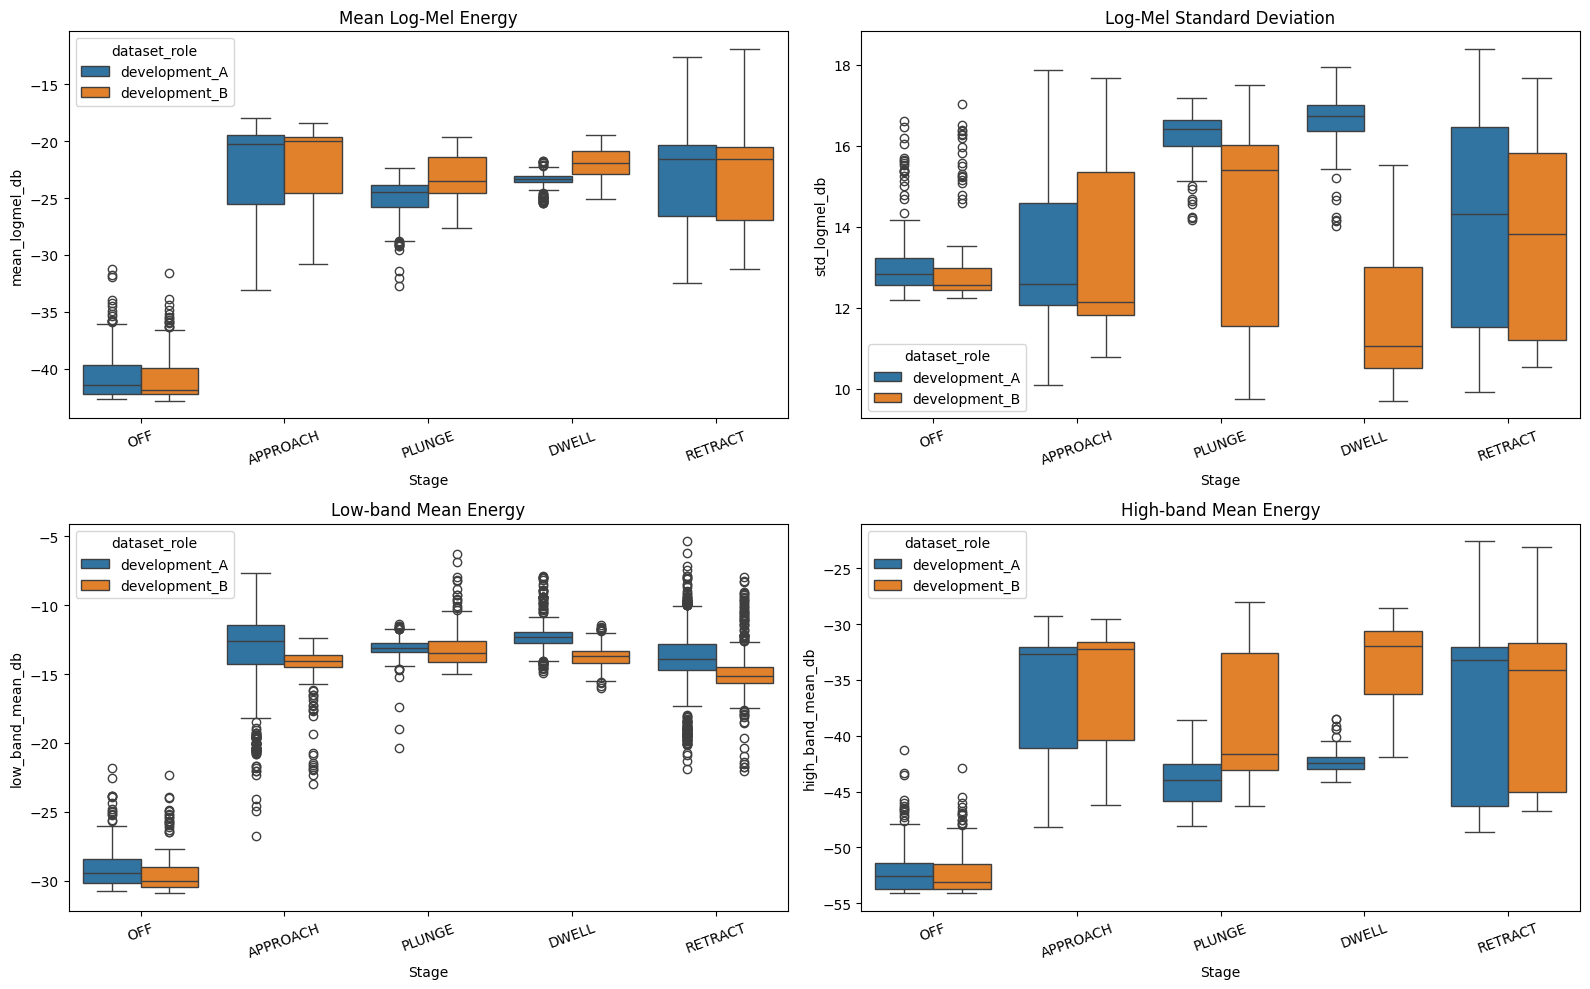

In [51]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

plot_features = [
    "mean_logmel_db",
    "std_logmel_db",
    "low_band_mean_db",
    "high_band_mean_db"
]

plot_titles = [
    "Mean Log-Mel Energy",
    "Log-Mel Standard Deviation",
    "Low-band Mean Energy",
    "High-band Mean Energy"
]

for axis, feature, title in zip(
    axes.flat,
    plot_features,
    plot_titles
):
    sns.boxplot(
        data=distribution_data,
        x="stage",
        y=feature,
        hue="dataset_role",
        order=stage_names,
        ax=axis
    )

    axis.set_title(title)
    axis.set_xlabel("Stage")
    axis.tick_params(
        axis="x",
        rotation=20
    )

plt.tight_layout()
plt.show()

## 경계 주변 hard label과 soft label 검사

각 공정 경계 주변에서 윈도우의 정답이 의도한 방식으로 변화하는지 확인한다.

development_A의 각 경계 종류에서 첫 번째 사례를 선택하고 경계 전후 윈도우에 대해 다음 값을 출력한다.

- 실험 번호와 window index
- 윈도우 시작 시각
- 중심 시점의 hard stage
- 각 stage의 포함 비율
- 경계 포함 여부
- 경계 이전 stage와 이후 stage

hard stage는 윈도우 중심 시점의 stage이며, soft label은 1초 윈도우에 포함된 각 stage의 시간 비율이다.

In [52]:
boundary_examples = (
    timeline_manifest[
        (
            timeline_manifest[
                "dataset_role"
            ] == "development_A"
        )
        & (
            timeline_manifest[
                "boundary_present"
            ]
        )
    ]
    .dropna(
        subset=[
            "from_stage",
            "to_stage"
        ]
    )
    .copy()
)

boundary_examples[
    "transition"
] = (
    boundary_examples[
        "from_stage"
    ].astype(str)
    + " -> "
    + boundary_examples[
        "to_stage"
    ].astype(str)
)

selected_boundaries = (
    boundary_examples
    .sort_values(
        [
            "experiment_id",
            "window_index"
        ]
    )
    .drop_duplicates(
        subset=["transition"]
    )
)

label_audit_records = []

for _, boundary_row in (
    selected_boundaries.iterrows()
):
    experiment_id = int(
        boundary_row[
            "experiment_id"
        ]
    )

    boundary_sec = float(
        boundary_row[
            "boundary_sec"
        ]
    )

    experiment_rows = (
        timeline_manifest[
            (
                timeline_manifest[
                    "dataset_role"
                ] == "development_A"
            )
            & (
                timeline_manifest[
                    "experiment_id"
                ] == experiment_id
            )
            & (
                timeline_manifest[
                    "window_center_sec"
                ].between(
                    boundary_sec - 1.0,
                    boundary_sec + 1.0
                )
            )
        ]
        .copy()
    )

    experiment_rows[
        "transition"
    ] = boundary_row[
        "transition"
    ]

    experiment_rows[
        "relative_to_boundary_sec"
    ] = (
        experiment_rows[
            "window_center_sec"
        ]
        - boundary_sec
    )

    label_audit_records.append(
        experiment_rows
    )

boundary_label_audit = pd.concat(
    label_audit_records,
    ignore_index=True
)

columns_to_show = [
    "transition",
    "experiment_id",
    "window_index",
    "relative_to_boundary_sec",
    "center_stage",
    "target_off",
    "target_approach",
    "target_plunge",
    "target_dwell",
    "target_retract",
    "boundary_present"
]

display(
    boundary_label_audit[
        columns_to_show
    ].round(3)
)

,transition,experiment_id,window_index,relative_to_boundary_sec,center_stage,target_off,target_approach,target_plunge,target_dwell,target_retract,boundary_present
0,off -> approach,1,2,-1.00,off,1.00,0.00,0.00,0.00,0.00,False
1,off -> approach,1,3,-0.75,off,1.00,0.00,0.00,0.00,0.00,False
2,off -> approach,1,4,-0.50,off,1.00,0.00,0.00,0.00,0.00,False
3,off -> approach,1,5,-0.25,off,0.75,0.25,0.00,0.00,0.00,True
4,off -> approach,1,6,0.00,approach,0.50,0.50,0.00,0.00,0.00,True
5,off -> approach,1,7,0.25,approach,0.25,0.75,0.00,0.00,0.00,True
6,off -> approach,1,8,0.50,approach,0.00,1.00,0.00,0.00,0.00,False
7,off -> approach,1,9,0.75,approach,0.00,1.00,0.00,0.00,0.00,False
8,off -> approach,1,10,1.00,approach,0.00,1.00,0.00,0.00,0.00,False
9,approach -> plunge,1,53,-0.76,approach,0.00,1.00,0.00,0.00,0.00,False


## 원본 파형과 선형 주파수 특징 비교

Mel-spectrogram 이외의 음향 특징에서도 development_A와 development_B 사이의 분포 차이가 발생하는지 확인한다.

경계에 두 stage가 섞인 영향을 제거하기 위해 `boundary_present=False`인 순수 stage 윈도우만 분석한다.

원본 48 kHz 파형에서 다음 특징을 계산한다.

### 시간 영역 특징

- **RMS dBFS**: 윈도우의 평균 음향 크기
- **Peak dBFS**: 윈도우의 최대 진폭
- **Crest factor**: 최대 진폭을 RMS로 나눈 값으로 순간 충격성 표현
- **Zero-crossing rate**: 파형이 0을 통과하는 빈도로 고주파 및 잡음 특성 표현
- **Envelope variation**: 짧은 구간 RMS가 시간에 따라 변하는 정도

### 선형 주파수 특징

Mel filter를 적용하지 않은 일반 STFT를 사용한다.

- **Spectral centroid**: 주파수 에너지의 중심
- **Spectral bandwidth**: 주파수 분포의 폭
- **Spectral rolloff**: 전체 에너지의 85%가 포함되는 주파수
- **Spectral flatness**: 음향이 특정 주파수에 집중됐는지 잡음처럼 퍼졌는지 표현
- **대역별 에너지**: 0~500 Hz, 500~2 kHz, 2~5 kHz, 5~12 kHz

각 연속 음원을 한 번만 읽은 뒤 해당 음원의 모든 윈도우를 처리하여 Google Drive 읽기 횟수를 줄인다.

In [53]:
PURE_STAGE_ONLY = True

analysis_manifest = (
    timeline_manifest[
        timeline_manifest[
            "dataset_role"
        ].isin(
            [
                "development_A",
                "development_B"
            ]
        )
    ]
    .copy()
)

if PURE_STAGE_ONLY:
    analysis_manifest = (
        analysis_manifest[
            ~analysis_manifest[
                "boundary_present"
            ].astype(bool)
        ]
        .copy()
    )

analysis_manifest = (
    analysis_manifest
    .sort_values(
        [
            "dataset_role",
            "experiment_id",
            "window_index"
        ]
    )
    .reset_index(drop=True)
)

print(
    "분석 대상 윈도우:",
    len(analysis_manifest)
)

display(
    analysis_manifest
    .groupby(
        [
            "dataset_role",
            "center_stage"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

분석 대상 윈도우: 3164


center_stage,approach,dwell,off,plunge,retract
dataset_role,,,,,
development_A,423,216,81,207,654
development_B,423,216,81,207,656


In [54]:
def amplitude_to_db(
    amplitude,
    epsilon=1e-12
):
    return 20.0 * np.log10(
        max(
            float(amplitude),
            epsilon
        )
    )


def calculate_band_power_db(
    power_spectrogram,
    frequencies,
    low_frequency,
    high_frequency
):
    frequency_mask = (
        (frequencies >= low_frequency)
        & (frequencies < high_frequency)
    )

    if not frequency_mask.any():
        return np.nan

    band_power = (
        power_spectrogram[
            frequency_mask
        ].mean()
    )

    return 10.0 * np.log10(
        max(
            float(band_power),
            1e-12
        )
    )


def extract_raw_audio_features(
    waveform,
    sample_rate
):
    waveform = np.asarray(
        waveform,
        dtype=np.float32
    )

    waveform = waveform - waveform.mean()

    rms = np.sqrt(
        np.mean(
            waveform ** 2
        )
    )

    peak = np.max(
        np.abs(waveform)
    )

    crest_factor = (
        peak
        / max(
            rms,
            1e-12
        )
    )

    zero_crossing_rate = np.mean(
        (
            waveform[:-1]
            * waveform[1:]
        ) < 0
    )

    stft_complex = librosa.stft(
        waveform,
        n_fft=2048,
        hop_length=512,
        window="hann",
        center=False
    )

    magnitude = np.abs(
        stft_complex
    )

    power = magnitude ** 2

    frequencies = librosa.fft_frequencies(
        sr=sample_rate,
        n_fft=2048
    )

    centroid = librosa.feature.spectral_centroid(
        S=magnitude,
        sr=sample_rate
    ).mean()

    bandwidth = librosa.feature.spectral_bandwidth(
        S=magnitude,
        sr=sample_rate
    ).mean()

    rolloff = librosa.feature.spectral_rolloff(
        S=magnitude,
        sr=sample_rate,
        roll_percent=0.85
    ).mean()

    flatness = librosa.feature.spectral_flatness(
        S=power
    ).mean()

    frame_rms = librosa.feature.rms(
        S=magnitude,
        frame_length=2048,
        hop_length=512
    )[0]

    envelope_variation = (
        frame_rms.std()
        / max(
            frame_rms.mean(),
            1e-12
        )
    )

    return {
        "rms_dbfs": amplitude_to_db(
            rms
        ),
        "peak_dbfs": amplitude_to_db(
            peak
        ),
        "crest_factor": float(
            crest_factor
        ),
        "zero_crossing_rate": float(
            zero_crossing_rate
        ),
        "envelope_variation": float(
            envelope_variation
        ),
        "spectral_centroid_hz": float(
            centroid
        ),
        "spectral_bandwidth_hz": float(
            bandwidth
        ),
        "spectral_rolloff_hz": float(
            rolloff
        ),
        "spectral_flatness": float(
            flatness
        ),
        "band_0_500_db": (
            calculate_band_power_db(
                power,
                frequencies,
                0,
                500
            )
        ),
        "band_500_2000_db": (
            calculate_band_power_db(
                power,
                frequencies,
                500,
                2000
            )
        ),
        "band_2000_5000_db": (
            calculate_band_power_db(
                power,
                frequencies,
                2000,
                5000
            )
        ),
        "band_5000_12000_db": (
            calculate_band_power_db(
                power,
                frequencies,
                5000,
                12000
            )
        )
    }

In [55]:
raw_feature_records = []

grouped_audio_files = (
    analysis_manifest.groupby(
        [
            "dataset_role",
            "experiment_id",
            "relative_path"
        ],
        sort=True
    )
)

total_audio_files = len(
    grouped_audio_files
)

for file_number, (
    (
        dataset_role,
        experiment_id,
        relative_path
    ),
    file_rows
) in enumerate(
    grouped_audio_files,
    start=1
):
    audio_path = (
        PROJECT_DIR
        / relative_path
    )

    waveform, sample_rate = sf.read(
        audio_path,
        dtype="float32",
        always_2d=False
    )

    if waveform.ndim == 2:
        waveform = waveform.mean(
            axis=1
        )

    for _, row in file_rows.iterrows():
        start_frame = int(
            round(
                row["window_start_sec"]
                * sample_rate
            )
        )

        end_frame = int(
            round(
                row["window_end_sec"]
                * sample_rate
            )
        )

        window_waveform = waveform[
            start_frame:end_frame
        ]

        expected_frames = int(
            round(
                (
                    row["window_end_sec"]
                    - row["window_start_sec"]
                )
                * sample_rate
            )
        )

        if (
            len(window_waveform)
            != expected_frames
        ):
            raise ValueError(
                f"윈도우 길이 오류: "
                f"{row['timeline_window_id']}"
            )

        feature_values = (
            extract_raw_audio_features(
                window_waveform,
                sample_rate
            )
        )

        raw_feature_records.append({
            "timeline_window_id": (
                row[
                    "timeline_window_id"
                ]
            ),
            "dataset_role": (
                dataset_role
            ),
            "experiment_id": int(
                experiment_id
            ),
            "window_index": int(
                row[
                    "window_index"
                ]
            ),
            "stage": (
                str(
                    row[
                        "center_stage"
                    ]
                ).upper()
            ),
            **feature_values
        })

    print(
        f"{file_number}/{total_audio_files} "
        f"음원 처리 완료: "
        f"experiment {experiment_id}"
    )

raw_feature_data = pd.DataFrame(
    raw_feature_records
)

print(
    "\n특징 추출 완료:",
    len(raw_feature_data)
)

display(
    raw_feature_data.head()
)

1/18 음원 처리 완료: experiment 1
2/18 음원 처리 완료: experiment 2
3/18 음원 처리 완료: experiment 3
4/18 음원 처리 완료: experiment 4
5/18 음원 처리 완료: experiment 5
6/18 음원 처리 완료: experiment 6
7/18 음원 처리 완료: experiment 7
8/18 음원 처리 완료: experiment 8
9/18 음원 처리 완료: experiment 9
10/18 음원 처리 완료: experiment 10
11/18 음원 처리 완료: experiment 11
12/18 음원 처리 완료: experiment 12
13/18 음원 처리 완료: experiment 13
14/18 음원 처리 완료: experiment 14
15/18 음원 처리 완료: experiment 15
16/18 음원 처리 완료: experiment 16
17/18 음원 처리 완료: experiment 17
18/18 음원 처리 완료: experiment 18

특징 추출 완료: 3164


,timeline_window_id,dataset_role,experiment_id,window_index,stage,rms_dbfs,peak_dbfs,crest_factor,zero_crossing_rate,envelope_variation,spectral_centroid_hz,spectral_bandwidth_hz,spectral_rolloff_hz,spectral_flatness,band_0_500_db,band_500_2000_db,band_2000_5000_db,band_5000_12000_db
0,timeline_000001,development_A,1,0,OFF,-44.996505,-35.757119,2.897139,0.030876,0.173672,2532.022240,4834.662345,4888.802083,2.445303e-08,0.523382,-23.352479,-26.504990,-38.184082
1,timeline_000002,development_A,1,1,OFF,-44.970391,-34.197353,3.456622,0.031313,0.164970,2551.077445,4848.394314,5013.281250,2.598851e-08,0.349170,-23.354721,-26.544448,-38.197840
2,timeline_000003,development_A,1,2,OFF,-45.179527,-34.184353,3.546163,0.033897,0.185141,2569.774279,4860.698095,5062.239583,3.015893e-08,0.235751,-23.358338,-26.571821,-38.206074
3,timeline_000004,development_A,1,3,OFF,-44.985029,-34.178546,3.469957,0.035147,0.192024,2560.529188,4851.549297,5130.208333,3.042807e-08,0.394179,-23.178139,-26.485702,-38.171702
4,timeline_000005,development_A,1,4,OFF,-45.068084,-34.184823,3.500766,0.036751,0.209622,2580.575669,4862.531577,5167.708333,3.651374e-08,0.305240,-23.212905,-26.329229,-38.133634


## 원본 음향 특징의 A/B 분포 차이 계산

각 stage에서 development_A와 development_B의 평균 및 Cohen's d를 계산한다.

`|Cohen's d| ≥ 0.8`인 경우 반복 간 차이가 큰 특징으로 분류한다. Mel-spectrogram뿐 아니라 RMS, 주파수 중심, 대역별 에너지 등에서도 큰 차이가 나타난다면 실제 원본 음향의 반복 재현성이 낮은 것으로 판단할 수 있다.

In [56]:
raw_feature_columns = [
    "rms_dbfs",
    "peak_dbfs",
    "crest_factor",
    "zero_crossing_rate",
    "envelope_variation",
    "spectral_centroid_hz",
    "spectral_bandwidth_hz",
    "spectral_rolloff_hz",
    "spectral_flatness",
    "band_0_500_db",
    "band_500_2000_db",
    "band_2000_5000_db",
    "band_5000_12000_db"
]

raw_comparison_records = []

for stage_name in stage_names:
    stage_rows = raw_feature_data[
        raw_feature_data[
            "stage"
        ] == stage_name
    ]

    for feature_name in (
        raw_feature_columns
    ):
        values_a = (
            stage_rows[
                stage_rows[
                    "dataset_role"
                ] == "development_A"
            ][feature_name]
            .dropna()
            .to_numpy()
        )

        values_b = (
            stage_rows[
                stage_rows[
                    "dataset_role"
                ] == "development_B"
            ][feature_name]
            .dropna()
            .to_numpy()
        )

        raw_comparison_records.append({
            "stage": stage_name,
            "feature": feature_name,
            "A_mean": np.mean(
                values_a
            ),
            "B_mean": np.mean(
                values_b
            ),
            "B_minus_A": (
                np.mean(values_b)
                - np.mean(values_a)
            ),
            "cohens_d": (
                calculate_cohens_d(
                    values_a,
                    values_b
                )
            )
        })

raw_feature_comparison = pd.DataFrame(
    raw_comparison_records
)

raw_feature_comparison[
    "absolute_cohens_d"
] = raw_feature_comparison[
    "cohens_d"
].abs()

display(
    raw_feature_comparison
    .sort_values(
        "absolute_cohens_d",
        ascending=False
    )
    .round(3)
)

,stage,feature,A_mean,B_mean,B_minus_A,cohens_d,absolute_cohens_d
51,DWELL,band_5000_12000_db,-30.285,-17.529,12.756,4.581,4.581
45,DWELL,spectral_bandwidth_hz,2202.942,2730.695,527.753,3.725,3.725
44,DWELL,spectral_centroid_hz,2293.071,2940.915,647.844,3.434,3.434
46,DWELL,spectral_rolloff_hz,3883.565,5252.854,1369.289,2.610,2.610
47,DWELL,spectral_flatness,0.000,0.000,0.000,2.153,2.153
...,...,...,...,...,...,...,...
3,OFF,zero_crossing_rate,0.033,0.033,0.000,0.023,0.023
35,PLUNGE,band_0_500_db,4.705,4.655,-0.050,-0.019,0.019
25,APPROACH,band_5000_12000_db,-18.230,-18.119,0.111,0.018,0.018
21,APPROACH,spectral_flatness,0.000,0.000,-0.000,-0.014,0.014


In [57]:
large_raw_feature_shifts = (
    raw_feature_comparison[
        raw_feature_comparison[
            "absolute_cohens_d"
        ] >= 0.8
    ]
    .sort_values(
        "absolute_cohens_d",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "큰 분포 차이를 보인 항목 수:",
    len(large_raw_feature_shifts)
)

display(
    large_raw_feature_shifts.round(3)
)

큰 분포 차이를 보인 항목 수: 17


,stage,feature,A_mean,B_mean,B_minus_A,cohens_d,absolute_cohens_d
0,DWELL,band_5000_12000_db,-30.285,-17.529,12.756,4.581,4.581
1,DWELL,spectral_bandwidth_hz,2202.942,2730.695,527.753,3.725,3.725
2,DWELL,spectral_centroid_hz,2293.071,2940.915,647.844,3.434,3.434
3,DWELL,spectral_rolloff_hz,3883.565,5252.854,1369.289,2.610,2.610
4,DWELL,spectral_flatness,0.000,0.000,0.000,2.153,2.153
5,APPROACH,band_0_500_db,7.783,4.418,-3.366,-1.448,1.448
6,DWELL,zero_crossing_rate,0.095,0.108,0.013,1.378,1.378
7,DWELL,envelope_variation,0.108,0.143,0.035,1.253,1.253
8,PLUNGE,rms_dbfs,-34.762,-33.471,1.291,1.078,1.078
9,PLUNGE,band_5000_12000_db,-30.458,-24.983,5.475,1.052,1.052
